In [332]:
import pandas as pd
import numpy as np


In [333]:
clinical = pd.read_csv(
    "TCGA_BRCA_Clinica_information_with_vital_status_and_days_to_death.txt",
    sep="\t",
    index_col=0
)

In [334]:
mol_status = pd.read_csv(
    "TCGA_BRCA_subset_of_clinical_supplement_information_all_patients.csv",
    sep=",",
    index_col=0
)

In [335]:
death_data = pd.read_csv(
    "TCGA_BRCA_vital_status_info.csv",
    sep=","
)

In [336]:
clinical

,project,submitter_id,morphology,tissue_or_organ_of_origin,age_at_diagnosis,primary_diagnosis,classification_of_tumor,updated_datetime,diagnosis_id,site_of_resection_or_biopsy,...,treatments_radiation_prescribed_dose_units,treatments_radiation_route_of_administration,treatments_radiation_prescribed_dose,treatments_radiation_number_of_cycles,bcr_patient_barcode,days_to_death.x,days_to_death.y,vital_status_gdc,year_of_death,id
1,TCGA-BRCA,TCGA-3C-AAAU,8520/3,"Breast, NOS",20211.0,"Lobular carcinoma, NOS",primary,2025-12-06T12:00:39.149033-06:00,8cfb8afb-b915-5255-865b-a5923f47b351,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-3C-AAAU,NaN,NaN,Alive,NaN,6e7d5ec6-a469-467c-b748-237353c23416
2,TCGA-BRCA,TCGA-3C-AALI,8500/3,"Breast, NOS",18538.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T10:18:03.012755-06:00,8cafc022-585f-54a1-a7d4-cfa632b3991e,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-3C-AALI,NaN,NaN,Alive,NaN,55262fcb-1b01-4480-b322-36570430c917
3,TCGA-BRCA,TCGA-3C-AALJ,8500/3,"Breast, NOS",22848.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T10:48:47.991777-06:00,63d85b81-8eba-5f17-8552-92babf137c00,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-3C-AALJ,NaN,NaN,Alive,NaN,427d0648-3f77-4ffc-b52c-89855426d647
4,TCGA-BRCA,TCGA-3C-AALK,8500/3,"Breast, NOS",19074.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T10:27:18.453133-06:00,8c90b19d-54f7-5788-a5eb-49abe239ef0b,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-3C-AALK,NaN,NaN,Alive,NaN,c31900a4-5dcd-4022-97ac-638e86e889e4
5,TCGA-BRCA,TCGA-4H-AAAK,8520/3,"Breast, NOS",18371.0,"Lobular carcinoma, NOS",primary,2025-12-06T10:25:54.674740-06:00,81c406cd-ad2d-552f-b543-8b2b03044686,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-4H-AAAK,NaN,NaN,Alive,NaN,6623fc5e-00be-4476-967a-cbd55f676ea6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,TCGA-BRCA,TCGA-WT-AB44,8520/3,"Breast, NOS",NaN,"Lobular carcinoma, NOS",primary,2025-12-06T12:07:31.492127-06:00,33236260-b983-5d95-a2ec-93e3169009ed,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-WT-AB44,NaN,NaN,Alive,NaN,5cd79093-1571-4f71-8136-0d84ccabdcac
961,TCGA-BRCA,TCGA-XX-A899,8520/3,"Breast, NOS",17022.0,"Lobular carcinoma, NOS",primary,2025-12-06T12:38:16.417999-06:00,f679d020-6da0-54c3-9904-8bfbbd2c5a57,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-XX-A899,NaN,NaN,Alive,NaN,f89588e9-ca73-4465-a7fb-7246edb45e3a
962,TCGA-BRCA,TCGA-XX-A89A,8520/3,"Breast, NOS",25000.0,"Lobular carcinoma, NOS",primary,2025-12-06T12:37:54.033938-06:00,d171e32b-7c5c-52ec-b98a-cb5509bae812,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-XX-A89A,NaN,NaN,Alive,NaN,ca20249f-b7ea-4fd9-9ecb-34f74755ae35
963,TCGA-BRCA,TCGA-Z7-A8R5,8520/3,"Breast, NOS",22280.0,"Lobular carcinoma, NOS",primary,2025-12-06T12:09:31.229860-06:00,3b46c06d-3232-5ebe-a91b-f3e8a1aedf1e,"Breast, NOS",...,NaN,NaN,NaN,NaN,TCGA-Z7-A8R5,NaN,NaN,Alive,NaN,23f438bd-1dbb-4d46-972f-1e8e74ddbd37


In [337]:
death_data

,days_to_death,vital_status_gdc,year_of_death,id,submitter_id
0,NaN,NaN,NaN,57a1604c-60b7-4b30-a75e-f70939532c5c,TCGA-BH-A0B2
1,NaN,Alive,NaN,2779fa01-ac93-4e80-a997-3385f72172c3,TCGA-A8-A08S
2,NaN,Alive,NaN,80f3f48a-cc21-415c-b181-c77e7ba1c563,TCGA-A8-A09C
3,2712.0,Dead,NaN,e663954c-05a8-479a-a623-400c1eb5efc6,TCGA-BH-A1F5
4,723.0,Dead,NaN,14b95463-2108-4921-afc2-e29eef52b18f,TCGA-A2-A0YT
...,...,...,...,...,...
1093,NaN,Alive,NaN,dfd0b7ba-c7d3-498e-b455-346301865452,TCGA-AC-A23C
1094,NaN,Alive,NaN,16368c32-2118-4fcf-8693-6c89995e49d8,TCGA-A1-A0SI
1095,NaN,Alive,NaN,ac075bc0-1b59-4557-beea-541694faee03,TCGA-E9-A1N8
1096,7455.0,Dead,NaN,178b2c48-c07d-422e-ae17-8bcfd996ad51,TCGA-B6-A0X1


In [338]:
death_data = death_data[["vital_status_gdc", "submitter_id"]]

In [339]:
death_data

,vital_status_gdc,submitter_id
0,NaN,TCGA-BH-A0B2
1,Alive,TCGA-A8-A08S
2,Alive,TCGA-A8-A09C
3,Dead,TCGA-BH-A1F5
4,Dead,TCGA-A2-A0YT
...,...,...
1093,Alive,TCGA-AC-A23C
1094,Alive,TCGA-A1-A0SI
1095,Alive,TCGA-E9-A1N8
1096,Dead,TCGA-B6-A0X1


In [340]:
mol_status

,age_at_diagnosis,er_status_by_ihc,pr_status_by_ihc,her2_status_by_ihc,ajcc_pathologic_tumor_stage,ajcc_tumor_pathologic_pt,ajcc_nodes_pathologic_pn,ajcc_metastasis_pathologic_pm,vital_status,death_days_to,last_contact_days_to,days_to_patient_progression_free,days_to_tumor_progression
bcr_patient_barcode,,,,,,,,,,,,,
TCGA-3C-AAAU,55,Positive,Positive,Negative,Stage X,TX,NX,MX,Alive,[Not Applicable],3767,[Not Available],[Not Available]
TCGA-3C-AALI,50,Positive,Positive,Positive,Stage IIB,T2,N1a,M0,Alive,[Not Applicable],3801,[Not Available],[Not Available]
TCGA-3C-AALJ,62,Positive,Positive,Indeterminate,Stage IIB,T2,N1a,M0,Alive,[Not Applicable],1228,[Not Available],[Not Available]
TCGA-3C-AALK,52,Positive,Positive,Positive,Stage IA,T1c,N0 (i+),M0,Alive,[Not Applicable],1217,[Not Available],[Not Available]
TCGA-4H-AAAK,50,Positive,Positive,Equivocal,Stage IIIA,T2,N2a,M0,Alive,[Not Applicable],158,[Not Available],[Not Available]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-WT-AB44,77,Positive,Positive,Negative,Stage IA,T1c,N0 (i-),MX,Alive,[Not Applicable],791,[Not Available],[Not Available]
TCGA-XX-A899,46,Positive,Positive,Negative,Stage IIIA,T1c,N2a,MX,Alive,[Not Applicable],292,[Not Available],[Not Available]
TCGA-XX-A89A,68,Positive,Positive,Negative,Stage IIB,T3,N0,MX,Alive,[Not Applicable],278,[Not Available],[Not Available]


In [341]:
mol_status["OS_time"] = np.where(
    mol_status["vital_status"] == "Dead",
    mol_status["death_days_to"],
    mol_status["last_contact_days_to"]
)

mol_status["OS_event"] = np.where(
    mol_status["vital_status"] == "Dead",
    1,
    0
)

In [342]:
mol_status

,age_at_diagnosis,er_status_by_ihc,pr_status_by_ihc,her2_status_by_ihc,ajcc_pathologic_tumor_stage,ajcc_tumor_pathologic_pt,ajcc_nodes_pathologic_pn,ajcc_metastasis_pathologic_pm,vital_status,death_days_to,last_contact_days_to,days_to_patient_progression_free,days_to_tumor_progression,OS_time,OS_event
bcr_patient_barcode,,,,,,,,,,,,,,,
TCGA-3C-AAAU,55,Positive,Positive,Negative,Stage X,TX,NX,MX,Alive,[Not Applicable],3767,[Not Available],[Not Available],3767,0
TCGA-3C-AALI,50,Positive,Positive,Positive,Stage IIB,T2,N1a,M0,Alive,[Not Applicable],3801,[Not Available],[Not Available],3801,0
TCGA-3C-AALJ,62,Positive,Positive,Indeterminate,Stage IIB,T2,N1a,M0,Alive,[Not Applicable],1228,[Not Available],[Not Available],1228,0
TCGA-3C-AALK,52,Positive,Positive,Positive,Stage IA,T1c,N0 (i+),M0,Alive,[Not Applicable],1217,[Not Available],[Not Available],1217,0
TCGA-4H-AAAK,50,Positive,Positive,Equivocal,Stage IIIA,T2,N2a,M0,Alive,[Not Applicable],158,[Not Available],[Not Available],158,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-WT-AB44,77,Positive,Positive,Negative,Stage IA,T1c,N0 (i-),MX,Alive,[Not Applicable],791,[Not Available],[Not Available],791,0
TCGA-XX-A899,46,Positive,Positive,Negative,Stage IIIA,T1c,N2a,MX,Alive,[Not Applicable],292,[Not Available],[Not Available],292,0
TCGA-XX-A89A,68,Positive,Positive,Negative,Stage IIB,T3,N0,MX,Alive,[Not Applicable],278,[Not Available],[Not Available],278,0


In [343]:
mol_status_use = mol_status[["er_status_by_ihc", "pr_status_by_ihc", "her2_status_by_ihc","ajcc_pathologic_tumor_stage"]]

In [344]:
mol_status_use["er_status_by_ihc"].value_counts()

er_status_by_ihc
Positive           808
Negative           238
[Not Evaluated]     49
Indeterminate        2
Name: count, dtype: int64

In [345]:
mol_status_use = mol_status_use[mol_status_use["er_status_by_ihc"].isin(["Positive", "Negative"])]

In [346]:
mol_status_use["er_status_by_ihc"].value_counts()

er_status_by_ihc
Positive    808
Negative    238
Name: count, dtype: int64

In [347]:
exp_data = pd.read_csv(
    "TCGA_BRCA_VSD_transformed_expression_matrix_above_75th_quantile_variance_overlapping_patients.csv",
    sep=",",
    index_col=0
)

In [348]:
exp_data

,TCGA-A7-A0DC,TCGA-BH-A0B6,TCGA-A8-A084,TCGA-A8-A06U,TCGA-D8-A146,TCGA-A8-A09K,TCGA-C8-A1HI,TCGA-B6-A1KC,TCGA-PL-A8LV,TCGA-E2-A1L7,...,TCGA-A8-A09N,TCGA-A8-A094,TCGA-AR-A24P,TCGA-A8-A0A1,TCGA-BH-A1EX,TCGA-BH-A204,TCGA-BH-A1FJ,TCGA-A8-A081,TCGA-A8-A09G,TCGA-A1-A0SF
ENSG00000000003.15,12.281793,10.944902,9.436177,11.428717,11.624694,11.068687,11.588461,10.916206,11.584126,11.174063,...,10.092051,12.262237,11.472167,11.892701,12.393158,9.620586,11.159879,12.997104,11.071712,13.327855
ENSG00000000971.16,10.103367,11.688588,11.481397,10.836507,11.747974,10.698056,11.803201,11.140024,11.135222,11.538419,...,11.291298,12.723185,11.460371,11.571588,12.413721,11.678929,10.262778,11.069776,11.330711,11.676899
ENSG00000001561.7,11.879582,11.552540,9.831606,11.316343,11.182561,10.264639,11.174784,12.359201,10.257153,10.474596,...,11.381828,12.084238,10.541624,10.577176,10.456138,12.414678,11.957356,10.895237,12.022969,8.824947
ENSG00000001617.12,12.015984,12.987438,14.010859,11.986202,12.512389,13.907958,12.243907,14.480071,11.220464,13.107525,...,13.818017,11.280810,13.364774,12.009907,11.622308,13.321589,12.382929,12.823587,12.667245,12.623880
ENSG00000002586.20,11.009406,13.592980,13.441111,12.818524,13.657548,11.356254,13.412123,11.489102,13.416344,13.092871,...,12.316866,14.527678,13.408144,13.059283,13.341463,11.677567,13.064604,12.517089,13.388379,13.081448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287826.1,8.124775,8.043853,6.807847,8.905604,7.891631,10.030253,11.435953,10.362130,7.018643,7.836831,...,8.848280,7.246223,9.490375,7.574908,7.046116,8.824913,8.455944,8.209589,7.082352,7.462584
ENSG00000287853.1,7.101321,7.439859,7.250942,7.517196,7.206396,7.302212,7.106541,7.159825,7.201341,7.600503,...,7.292365,7.246223,7.139886,7.124067,7.561098,7.021948,6.924020,7.160472,6.981616,7.462584
ENSG00000287900.1,9.934951,6.953940,8.151339,7.050948,7.950259,11.633505,7.942764,9.292597,7.065904,10.651451,...,6.807847,8.512462,7.425676,8.962454,8.685331,7.503703,6.807847,7.794590,6.981616,7.095579
ENSG00000287914.1,10.906179,8.028398,9.276883,8.932383,9.883833,11.132134,7.834846,8.975082,6.956969,8.830914,...,9.293643,7.450283,8.958968,10.472060,7.416151,9.589016,9.554228,9.374897,7.154758,9.234335


In [349]:
mut_status_data = pd.read_csv(
    "TCGA_BRCA_mutation_status_overlapping_patients.csv",
    sep=",",
    index_col=0
)

In [350]:
mut_count_data = pd.read_csv(
    "TCGA_BRCA_mutation_count_overlapping_patients.csv",
    sep=",",
    index_col=0
)

In [351]:
mut_status_data

,TCGA-3C-AAAU,TCGA-3C-AALI,TCGA-3C-AALJ,TCGA-3C-AALK,TCGA-4H-AAAK,TCGA-5L-AAT0,TCGA-5L-AAT1,TCGA-5T-A9QA,TCGA-A1-A0SB,TCGA-A1-A0SD,...,TCGA-UL-AAZ6,TCGA-UU-A93S,TCGA-V7-A7HQ,TCGA-W8-A86G,TCGA-WT-AB41,TCGA-WT-AB44,TCGA-XX-A899,TCGA-XX-A89A,TCGA-Z7-A8R5,TCGA-Z7-A8R6
CEP350_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTN_status,0,1,1,0,0,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
TLN1_status,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PTEN_status,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
NIPBL_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HR_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
MMP1_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZNF77_status,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PIP_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [352]:
mut_count_data

,TCGA-3C-AAAU,TCGA-3C-AALI,TCGA-3C-AALJ,TCGA-3C-AALK,TCGA-4H-AAAK,TCGA-5L-AAT0,TCGA-5L-AAT1,TCGA-5T-A9QA,TCGA-A1-A0SB,TCGA-A1-A0SD,...,TCGA-UL-AAZ6,TCGA-UU-A93S,TCGA-V7-A7HQ,TCGA-W8-A86G,TCGA-WT-AB41,TCGA-WT-AB44,TCGA-XX-A899,TCGA-XX-A89A,TCGA-Z7-A8R5,TCGA-Z7-A8R6
CEP350_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTN_count,0,1,1,0,0,1,2,0,0,0,...,0,1,0,0,0,0,0,0,0,0
TLN1_count,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PTEN_count,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
NIPBL_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HR_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
MMP1_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZNF77_count,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PIP_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [353]:
exp_data.columns.equals(mut_status_data.columns)

False

In [354]:
exp_data.columns.equals(mut_count_data.columns)

False

In [355]:
exp_data.shape[1]

1095

In [356]:
mut_status_data.shape[1]

964

In [36]:
# Find patients with mutation data and expression data and ER status data

In [357]:
overlap_exp_mut = exp_data.columns.intersection(mut_count_data.columns)

In [358]:
overlap_exp_mut

Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI', 'TCGA-B6-A1KC', 'TCGA-PL-A8LV', 'TCGA-E2-A1L7',
       'TCGA-AR-A0U0', 'TCGA-D8-A1XU',
       ...
       'TCGA-A8-A09N', 'TCGA-A8-A094', 'TCGA-AR-A24P', 'TCGA-A8-A0A1',
       'TCGA-BH-A1EX', 'TCGA-BH-A204', 'TCGA-BH-A1FJ', 'TCGA-A8-A081',
       'TCGA-A8-A09G', 'TCGA-A1-A0SF'],
      dtype='str', length=964)

In [359]:
#overlap_exp_mut.intersection(

In [360]:
print(len(overlap_exp_mut.intersection(mol_status_use.index)))

919


In [361]:
overlap_ids = [x for x in overlap_exp_mut if x in mol_status_use.index]

mol_status_use_overlap = mol_status_use.loc[overlap_ids]

In [362]:
mol_status_use_overlap

,er_status_by_ihc,pr_status_by_ihc,her2_status_by_ihc,ajcc_pathologic_tumor_stage
bcr_patient_barcode,,,,
TCGA-BH-A0B6,Positive,Positive,Positive,Stage I
TCGA-A8-A06U,Positive,Positive,Positive,Stage IIB
TCGA-D8-A146,Positive,Positive,Negative,Stage IIA
TCGA-A8-A09K,Positive,Positive,Negative,Stage IIA
TCGA-C8-A1HI,Positive,Positive,Negative,Stage IIIA
...,...,...,...,...
TCGA-BH-A1EX,Positive,Positive,Positive,Stage IIB
TCGA-BH-A1FJ,Negative,Positive,[Not Evaluated],Stage IIIA
TCGA-A8-A081,Positive,Positive,Negative,Stage IIA


In [363]:
row_indexes = mol_status_use_overlap.index.tolist()

In [364]:
len(row_indexes)

919

In [365]:
exp_data_overlap = exp_data[row_indexes]
mut_status_data_overlap = mut_status_data[row_indexes]
mut_count_data_overlap = mut_count_data[row_indexes]
clinical_overlap = clinical[clinical["submitter_id"].isin(row_indexes)]

In [366]:
mut_status_data_overlap

,TCGA-BH-A0B6,TCGA-A8-A06U,TCGA-D8-A146,TCGA-A8-A09K,TCGA-C8-A1HI,TCGA-B6-A1KC,TCGA-E2-A1L7,TCGA-AR-A0U0,TCGA-D8-A1XU,TCGA-B6-A0IK,...,TCGA-A8-A096,TCGA-A8-A09N,TCGA-A8-A094,TCGA-AR-A24P,TCGA-A8-A0A1,TCGA-BH-A1EX,TCGA-BH-A1FJ,TCGA-A8-A081,TCGA-A8-A09G,TCGA-A1-A0SF
CEP350_status,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTN_status,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
TLN1_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PTEN_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NIPBL_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HR_status,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MMP1_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
ZNF77_status,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
PIP_status,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [323]:
mut_status_data_overlap

,TCGA-BH-A0B6,TCGA-A8-A06U,TCGA-D8-A146,TCGA-A8-A09K,TCGA-C8-A1HI,TCGA-B6-A1KC,TCGA-E2-A1L7,TCGA-AR-A0U0,TCGA-D8-A1XU,TCGA-B6-A0IK,...,TCGA-A8-A096,TCGA-A8-A09N,TCGA-A8-A094,TCGA-AR-A24P,TCGA-A8-A0A1,TCGA-BH-A1EX,TCGA-BH-A1FJ,TCGA-A8-A081,TCGA-A8-A09G,TCGA-A1-A0SF
CEP350_status,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTN_status,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
TLN1_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PTEN_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NIPBL_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HR_status,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MMP1_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
ZNF77_status,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
PIP_status,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [367]:
patient_order = exp_data_overlap.columns.tolist()

clinical_overlap_o = (
    clinical_overlap
    .set_index("submitter_id")
    .loc[patient_order]
    .reset_index()
)

In [368]:
patient_order = clinical_overlap["submitter_id"].tolist()

# Expression: patients become rows
X = exp_data_overlap.T

# Clinical: patients become rows
clinical_overlap_o = clinical_overlap.set_index("submitter_id")

# Explicitly reorder clinical to exactly match X
clinical_overlap_o = clinical_overlap_o.loc[X.index]

In [369]:
X

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,ENSG00000286619.1,ENSG00000287151.1,ENSG00000287262.1,ENSG00000287550.1,ENSG00000287609.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287900.1,ENSG00000287914.1,ENSG00000287952.1
TCGA-BH-A0B6,10.944902,11.688588,11.552540,12.987438,13.592980,8.725340,12.078503,8.306847,11.155000,9.832461,...,7.164942,8.787026,9.021205,7.193390,7.014366,8.043853,7.439859,6.953940,8.028398,7.858496
TCGA-A8-A06U,11.428717,10.836507,11.316343,11.986202,12.818524,7.604899,10.297997,9.246294,11.234529,8.935691,...,9.248905,9.620988,7.489884,7.704043,7.006416,8.905604,7.517196,7.050948,8.932383,7.503684
TCGA-D8-A146,11.624694,11.747974,11.182561,12.512389,13.657548,8.423132,11.610453,8.882562,10.926540,9.936154,...,7.060391,9.249686,10.387318,11.627839,6.934240,7.891631,7.206396,7.950259,9.883833,9.317606
TCGA-A8-A09K,11.068687,10.698056,10.264639,13.907958,11.356254,7.322191,9.655225,8.562093,11.538314,8.918128,...,8.257063,8.310040,9.973501,6.807847,7.010493,10.030253,7.302212,11.633505,11.132134,8.332804
TCGA-C8-A1HI,11.588461,11.803201,11.174784,12.243907,13.412123,7.298459,11.419338,11.023680,10.839608,10.092533,...,7.347098,9.198694,8.152952,9.654901,6.807847,11.435953,7.106541,7.942764,7.834846,8.903213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-BH-A1EX,12.393158,12.413721,10.456138,11.622308,13.341463,7.546501,10.987215,7.629867,12.958906,9.719765,...,7.144430,8.586412,8.341829,7.756668,6.914501,7.046116,7.561098,8.685331,7.416151,6.807847
TCGA-BH-A1FJ,11.159879,10.262778,11.957356,12.382929,13.064604,7.008956,8.671428,8.248881,11.535360,8.906744,...,9.077606,9.067426,7.626677,10.897458,6.807847,8.455944,6.924020,6.807847,9.554228,7.092029
TCGA-A8-A081,12.997104,11.069776,10.895237,12.823587,12.517089,13.253854,10.761900,7.481683,10.659548,9.745821,...,6.807847,7.829078,8.787470,8.294233,6.807847,8.209589,7.160472,7.794590,9.374897,6.807847
TCGA-A8-A09G,11.071712,11.330711,12.022969,12.667245,13.388379,7.507257,10.505683,8.541708,11.191279,9.611939,...,8.358553,8.421564,9.531535,9.624138,6.981616,7.082352,6.981616,6.981616,7.154758,7.082352


In [370]:
clinical_overlap_o

,project,morphology,tissue_or_organ_of_origin,age_at_diagnosis,primary_diagnosis,classification_of_tumor,updated_datetime,diagnosis_id,site_of_resection_or_biopsy,state,...,treatments_radiation_prescribed_dose_units,treatments_radiation_route_of_administration,treatments_radiation_prescribed_dose,treatments_radiation_number_of_cycles,bcr_patient_barcode,days_to_death.x,days_to_death.y,vital_status_gdc,year_of_death,id
TCGA-BH-A0B6,TCGA-BRCA,8500/3,"Breast, NOS",17346.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T10:18:30.932165-06:00,aedb96c5-99f0-5db2-8223-6a71050e9d9a,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-BH-A0B6,NaN,NaN,Alive,NaN,fa4e082a-d213-412e-8d91-842a6f4bef12
TCGA-A8-A06U,TCGA-BRCA,8500/3,"Breast, NOS",29525.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T10:01:50.035441-06:00,2774667f-ef98-5f5c-91ea-d9aecc62c7d2,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-A8-A06U,883.0,883.0,Dead,NaN,6bc4c56d-aac5-49a2-9913-9538d06d898f
TCGA-D8-A146,TCGA-BRCA,8500/3,"Breast, NOS",20861.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T11:41:02.414558-06:00,7491803e-023c-5e55-85c3-77a79b28e86e,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-D8-A146,NaN,NaN,Alive,NaN,03da7a65-fa2f-42cb-a709-5fe8736f21d3
TCGA-A8-A09K,TCGA-BRCA,8500/3,"Breast, NOS",24960.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T12:59:07.761279-06:00,97c4714e-0498-563c-a089-e1039244a85e,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-A8-A09K,NaN,NaN,Alive,NaN,6f959c92-b79f-4f84-9ee5-d07d3212d52d
TCGA-C8-A1HI,TCGA-BRCA,8500/3,"Breast, NOS",NaN,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T10:09:37.106883-06:00,f0358f25-5b5c-58bd-bed7-7e56c7d72c1f,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-C8-A1HI,NaN,NaN,Alive,NaN,444374f8-9282-439c-af00-0f828edcbff3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-BH-A1EX,TCGA-BRCA,8500/3,"Breast, NOS",24544.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T13:44:05.170386-06:00,a4efd4cf-5f48-5763-b967-90ec07912682,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-BH-A1EX,1508.0,1508.0,Dead,NaN,7b892055-c59d-4550-8688-ad039790af3d
TCGA-BH-A1FJ,TCGA-BRCA,8500/3,"Breast, NOS",24262.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T09:52:50.649575-06:00,460fd561-3ea4-5af3-a702-11cf7032238a,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-BH-A1FJ,1927.0,1927.0,Dead,NaN,f6581eee-61b9-43d4-ab0d-ce5ce3ba1c74
TCGA-A8-A081,TCGA-BRCA,8500/3,"Breast, NOS",29555.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T12:59:37.910413-06:00,927cdbe8-4715-5fec-9fd4-56149a926e96,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-A8-A081,NaN,NaN,Alive,NaN,9d876f05-5080-4c4e-9bf5-45f631d381e5
TCGA-A8-A09G,TCGA-BRCA,8500/3,"Breast, NOS",29006.0,"Infiltrating duct carcinoma, NOS",primary,2025-12-06T10:25:35.063965-06:00,48f45df8-f904-5fe1-b675-c2fc39603faa,"Breast, NOS",released,...,NaN,NaN,NaN,NaN,TCGA-A8-A09G,NaN,NaN,Alive,NaN,3927f736-3b5c-48c8-9d9e-83669ec44770


In [371]:
#Check that ordering same of metadata and omics data

In [372]:
exp_data_overlap.columns.equals(clinical_overlap_o.index)

True

In [373]:
mut_status_data_overlap.columns.equals(clinical_overlap_o.index)

True

In [374]:
mut_count_data_overlap.columns.equals(clinical_overlap_o.index)

True

In [375]:
exp_data_overlap.columns.equals(mol_status_use_overlap.index)

True

In [376]:
exp_data_overlap.shape[1]

919

In [377]:
exp_data_overlap.index.tolist()

['ENSG00000000003.15',
 'ENSG00000000971.16',
 'ENSG00000001561.7',
 'ENSG00000001617.12',
 'ENSG00000002586.20',
 'ENSG00000002726.21',
 'ENSG00000002933.9',
 'ENSG00000003096.14',
 'ENSG00000003249.15',
 'ENSG00000003436.16',
 'ENSG00000003989.18',
 'ENSG00000004468.13',
 'ENSG00000004799.8',
 'ENSG00000004838.14',
 'ENSG00000005001.10',
 'ENSG00000005102.14',
 'ENSG00000005243.10',
 'ENSG00000005249.13',
 'ENSG00000005379.17',
 'ENSG00000005469.12',
 'ENSG00000005513.10',
 'ENSG00000005844.19',
 'ENSG00000005884.18',
 'ENSG00000006015.18',
 'ENSG00000006016.11',
 'ENSG00000006042.12',
 'ENSG00000006047.13',
 'ENSG00000006071.15',
 'ENSG00000006118.15',
 'ENSG00000006210.7',
 'ENSG00000006282.21',
 'ENSG00000006327.14',
 'ENSG00000006468.14',
 'ENSG00000006555.11',
 'ENSG00000006747.15',
 'ENSG00000006831.10',
 'ENSG00000007038.11',
 'ENSG00000007062.12',
 'ENSG00000007216.15',
 'ENSG00000007237.19',
 'ENSG00000007264.15',
 'ENSG00000007402.12',
 'ENSG00000007516.14',
 'ENSG000000079

In [378]:
assert exp_data_overlap.shape[1] == 919
assert clinical_overlap_o.shape[0] == 919
assert exp_data_overlap.index.is_unique
assert clinical_overlap_o.index.is_unique
assert exp_data_overlap.columns.tolist() == clinical_overlap_o.index.tolist()
assert exp_data_overlap.columns.tolist() == mol_status_use_overlap.index.tolist()


In [379]:
mol_status_use_overlap["patient_barcode"] = mol_status_use_overlap.index

In [380]:
mol_status_use_overlap

,er_status_by_ihc,pr_status_by_ihc,her2_status_by_ihc,ajcc_pathologic_tumor_stage,patient_barcode
bcr_patient_barcode,,,,,
TCGA-BH-A0B6,Positive,Positive,Positive,Stage I,TCGA-BH-A0B6
TCGA-A8-A06U,Positive,Positive,Positive,Stage IIB,TCGA-A8-A06U
TCGA-D8-A146,Positive,Positive,Negative,Stage IIA,TCGA-D8-A146
TCGA-A8-A09K,Positive,Positive,Negative,Stage IIA,TCGA-A8-A09K
TCGA-C8-A1HI,Positive,Positive,Negative,Stage IIIA,TCGA-C8-A1HI
...,...,...,...,...,...
TCGA-BH-A1EX,Positive,Positive,Positive,Stage IIB,TCGA-BH-A1EX
TCGA-BH-A1FJ,Negative,Positive,[Not Evaluated],Stage IIIA,TCGA-BH-A1FJ
TCGA-A8-A081,Positive,Positive,Negative,Stage IIA,TCGA-A8-A081


In [381]:
clinical_overlap_o["bcr_patient_barcode"].equals(mol_status_use_overlap["patient_barcode"])

True

In [382]:
clinical_only = clinical_overlap_o.index.difference(
    mol_status_use_overlap.index
)

molecular_only = mol_status_use_overlap.index.difference(
    clinical_overlap_o.index
)

print("Only in clinical_molecular:", len(clinical_only))
print(clinical_only.tolist())

print("Only in mol_status_use_overlap:", len(molecular_only))
print(molecular_only.tolist())

Only in clinical_molecular: 0
[]
Only in mol_status_use_overlap: 0
[]


In [383]:
clinical_molecular_use_overlap = clinical_overlap_o.loc[
    mol_status_use_overlap.index
]

In [384]:
## clinical_molecular_use_overlap with vital status data
clinical_molecular = clinical_molecular_use_overlap.set_index("bcr_patient_barcode")
# ER status
y = mol_status_use_overlap["er_status_by_ihc"]

In [385]:
y

bcr_patient_barcode
TCGA-BH-A0B6    Positive
TCGA-A8-A06U    Positive
TCGA-D8-A146    Positive
TCGA-A8-A09K    Positive
TCGA-C8-A1HI    Positive
                  ...   
TCGA-BH-A1EX    Positive
TCGA-BH-A1FJ    Negative
TCGA-A8-A081    Positive
TCGA-A8-A09G    Positive
TCGA-A1-A0SF    Positive
Name: er_status_by_ihc, Length: 919, dtype: str

In [386]:
import numpy as np

np.random.seed(123)

n = exp_data_overlap.shape[1]

train_id = np.random.choice(
    np.arange(n),
    size=int(np.floor(0.7 * n)),
    replace=False
)

test_id = np.setdiff1d(
    np.arange(n),
    train_id
)

In [387]:
print(exp_data_overlap.shape)
print(clinical_molecular_use_overlap.shape)

print(exp_data_overlap.index[:5])
print(clinical_molecular_use_overlap.index[:5])

(3796, 919)
(919, 62)
Index(['ENSG00000000003.15', 'ENSG00000000971.16', 'ENSG00000001561.7',
       'ENSG00000001617.12', 'ENSG00000002586.20'],
      dtype='str')
Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI'],
      dtype='str', name='bcr_patient_barcode')


In [388]:
X = exp_data_overlap.T

# Clinical labels: samples
y = mol_status_use_overlap["er_status_by_ihc"]

print(X.shape)
print(y.shape)

(919, 3796)
(919,)


In [389]:
print(X.index[:5])
print(y.index[:5])

assert X.index.equals(y.index)

Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI'],
      dtype='str')
Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI'],
      dtype='str', name='bcr_patient_barcode')


In [390]:
# Check for mismatch
print(X.index[:10])
print(y.index[:10])

print("X samples:", len(X.index))
print("y samples:", len(y.index))

print("Common samples:", len(X.index.intersection(y.index)))
print("X only:", len(X.index.difference(y.index)))
print("y only:", len(y.index.difference(X.index)))

Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI', 'TCGA-B6-A1KC', 'TCGA-E2-A1L7', 'TCGA-AR-A0U0',
       'TCGA-D8-A1XU', 'TCGA-B6-A0IK'],
      dtype='str')
Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI', 'TCGA-B6-A1KC', 'TCGA-E2-A1L7', 'TCGA-AR-A0U0',
       'TCGA-D8-A1XU', 'TCGA-B6-A0IK'],
      dtype='str', name='bcr_patient_barcode')
X samples: 919
y samples: 919
Common samples: 919
X only: 0
y only: 0


In [391]:
print(clinical_molecular.columns.tolist())

['project', 'morphology', 'tissue_or_organ_of_origin', 'age_at_diagnosis', 'primary_diagnosis', 'classification_of_tumor', 'updated_datetime', 'diagnosis_id', 'site_of_resection_or_biopsy', 'state', 'diagnosis_is_primary_disease', 'synchronous_malignancy', 'ajcc_pathologic_stage', 'days_to_diagnosis', 'laterality', 'prior_malignancy', 'year_of_diagnosis', 'prior_treatment', 'ajcc_pathologic_t', 'ajcc_pathologic_n', 'ajcc_pathologic_m', 'icd_10_code', 'sites_of_involvement', 'method_of_diagnosis', 'race', 'ethnicity', 'vital_status', 'age_at_index', 'days_to_birth', 'demographic_id', 'age_is_obfuscated', 'sex_at_birth', 'days_to_last_follow_up', 'follow_ups_disease_response', 'treatments_radiation_days_to_treatment_end', 'treatments_radiation_days_to_treatment_start', 'treatments_radiation_treatment_id', 'treatments_radiation_treatment_type', 'treatments_radiation_regimen_or_line_of_therapy', 'treatments_radiation_treatment_effect', 'treatments_radiation_therapeutic_agents', 'treatments

In [392]:
# Define expression and labels
X = exp_data_overlap.T
y = mol_status_use_overlap["er_status_by_ihc"]

print(X.shape)
print(y.shape)

print(X.index[:5])
print(y.index[:5])

(919, 3796)
(919,)
Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI'],
      dtype='str')
Index(['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K',
       'TCGA-C8-A1HI'],
      dtype='str', name='bcr_patient_barcode')


In [393]:
print("Common samples:", len(X.index.intersection(y.index)))
print("X only:", len(X.index.difference(y.index)))
print("y only:", len(y.index.difference(X.index)))

Common samples: 919
X only: 0
y only: 0


In [394]:
common_samples = X.index.intersection(y.index)

X = X.loc[common_samples]
y = y.loc[common_samples]

# Make absolutely sure they have identical ordering
X = X.loc[y.index]

assert X.index.equals(y.index)

In [395]:
X

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,ENSG00000286619.1,ENSG00000287151.1,ENSG00000287262.1,ENSG00000287550.1,ENSG00000287609.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287900.1,ENSG00000287914.1,ENSG00000287952.1
TCGA-BH-A0B6,10.944902,11.688588,11.552540,12.987438,13.592980,8.725340,12.078503,8.306847,11.155000,9.832461,...,7.164942,8.787026,9.021205,7.193390,7.014366,8.043853,7.439859,6.953940,8.028398,7.858496
TCGA-A8-A06U,11.428717,10.836507,11.316343,11.986202,12.818524,7.604899,10.297997,9.246294,11.234529,8.935691,...,9.248905,9.620988,7.489884,7.704043,7.006416,8.905604,7.517196,7.050948,8.932383,7.503684
TCGA-D8-A146,11.624694,11.747974,11.182561,12.512389,13.657548,8.423132,11.610453,8.882562,10.926540,9.936154,...,7.060391,9.249686,10.387318,11.627839,6.934240,7.891631,7.206396,7.950259,9.883833,9.317606
TCGA-A8-A09K,11.068687,10.698056,10.264639,13.907958,11.356254,7.322191,9.655225,8.562093,11.538314,8.918128,...,8.257063,8.310040,9.973501,6.807847,7.010493,10.030253,7.302212,11.633505,11.132134,8.332804
TCGA-C8-A1HI,11.588461,11.803201,11.174784,12.243907,13.412123,7.298459,11.419338,11.023680,10.839608,10.092533,...,7.347098,9.198694,8.152952,9.654901,6.807847,11.435953,7.106541,7.942764,7.834846,8.903213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-BH-A1EX,12.393158,12.413721,10.456138,11.622308,13.341463,7.546501,10.987215,7.629867,12.958906,9.719765,...,7.144430,8.586412,8.341829,7.756668,6.914501,7.046116,7.561098,8.685331,7.416151,6.807847
TCGA-BH-A1FJ,11.159879,10.262778,11.957356,12.382929,13.064604,7.008956,8.671428,8.248881,11.535360,8.906744,...,9.077606,9.067426,7.626677,10.897458,6.807847,8.455944,6.924020,6.807847,9.554228,7.092029
TCGA-A8-A081,12.997104,11.069776,10.895237,12.823587,12.517089,13.253854,10.761900,7.481683,10.659548,9.745821,...,6.807847,7.829078,8.787470,8.294233,6.807847,8.209589,7.160472,7.794590,9.374897,6.807847
TCGA-A8-A09G,11.071712,11.330711,12.022969,12.667245,13.388379,7.507257,10.505683,8.541708,11.191279,9.611939,...,8.358553,8.421564,9.531535,9.624138,6.981616,7.082352,6.981616,6.981616,7.154758,7.082352


In [396]:
y

TCGA-BH-A0B6    Positive
TCGA-A8-A06U    Positive
TCGA-D8-A146    Positive
TCGA-A8-A09K    Positive
TCGA-C8-A1HI    Positive
                  ...   
TCGA-BH-A1EX    Positive
TCGA-BH-A1FJ    Negative
TCGA-A8-A081    Positive
TCGA-A8-A09G    Positive
TCGA-A1-A0SF    Positive
Name: er_status_by_ihc, Length: 919, dtype: str

In [397]:
print("Expression IDs:")
print(X.index[:10].tolist())

print("\nClinical IDs:")
print(y.index[:10].tolist())

Expression IDs:
['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K', 'TCGA-C8-A1HI', 'TCGA-B6-A1KC', 'TCGA-E2-A1L7', 'TCGA-AR-A0U0', 'TCGA-D8-A1XU', 'TCGA-B6-A0IK']

Clinical IDs:
['TCGA-BH-A0B6', 'TCGA-A8-A06U', 'TCGA-D8-A146', 'TCGA-A8-A09K', 'TCGA-C8-A1HI', 'TCGA-B6-A1KC', 'TCGA-E2-A1L7', 'TCGA-AR-A0U0', 'TCGA-D8-A1XU', 'TCGA-B6-A0IK']


In [398]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [399]:
X_train

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,ENSG00000286619.1,ENSG00000287151.1,ENSG00000287262.1,ENSG00000287550.1,ENSG00000287609.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287900.1,ENSG00000287914.1,ENSG00000287952.1
TCGA-E2-A1IO,12.099262,12.386395,10.908703,12.023363,13.533357,7.446067,11.209716,10.291328,10.557846,10.344214,...,8.245179,9.259990,9.495959,8.780530,8.853338,7.972534,7.419304,8.030690,8.304882,7.484107
TCGA-A2-A0ER,11.504601,10.720461,11.702956,12.950066,13.167552,9.713615,13.925234,8.071858,12.108195,9.346869,...,8.186375,8.672445,7.870986,12.937477,8.527961,7.815001,7.275588,7.699017,9.227447,9.337147
TCGA-A2-A4RW,11.688412,11.101969,10.563184,13.266869,13.506760,8.864548,10.872088,10.516753,12.035225,10.096497,...,9.280657,8.989576,8.085434,7.100022,6.807847,7.878217,7.100022,7.948596,9.095253,8.065567
TCGA-BH-A0DL,11.793049,10.787856,10.123912,12.188057,11.975481,8.435923,11.410088,8.583773,10.925725,9.343534,...,9.843330,8.392891,7.422346,7.110614,7.110614,7.084318,9.281691,6.931640,7.269212,6.807847
TCGA-D8-A1XZ,10.835516,11.802696,9.027201,12.319220,12.825101,7.354370,10.178914,7.401345,10.799308,9.876473,...,7.783754,8.546619,8.622565,7.158633,7.042024,12.875253,7.288914,7.042024,7.609594,7.274676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-A8-A081,12.997104,11.069776,10.895237,12.823587,12.517089,13.253854,10.761900,7.481683,10.659548,9.745821,...,6.807847,7.829078,8.787470,8.294233,6.807847,8.209589,7.160472,7.794590,9.374897,6.807847
TCGA-3C-AALJ,11.710372,11.318850,9.013866,13.256055,13.549404,8.005098,13.819435,7.615503,13.047483,9.669111,...,7.228891,8.791909,8.053861,8.379100,6.807847,6.807847,7.436667,11.007317,8.583318,7.401217
TCGA-B6-A0WV,9.949471,9.647922,10.687243,13.326310,13.266789,7.172550,9.152573,9.472198,11.772785,8.921564,...,7.105889,8.708777,7.953024,8.084265,6.957067,7.400809,7.201598,9.050694,9.139858,8.247653
TCGA-AO-A124,11.405713,9.712266,11.042881,11.425159,13.095709,7.539080,9.961782,8.913752,9.941289,9.308111,...,9.492666,7.394551,7.250247,7.021009,7.298207,7.196206,7.803732,6.807847,6.807847,6.981946


In [400]:
mapping = {
    "Positive": 0,
    "Negative": 1
}

y_train = y_train.map(mapping).astype(np.int64)

y_train.value_counts().sort_index()

er_status_by_ihc
0    496
1    147
Name: count, dtype: int64

In [401]:
y_test = y_test.map(mapping).astype(np.int64)

y_test.value_counts().sort_index()

er_status_by_ihc
0    213
1     63
Name: count, dtype: int64

In [402]:
X_train_original = X_train.copy()
y_train_original = y_train.copy()

X_test_original = X_test.copy()
y_test_original = y_test.copy()

In [403]:
y_test_original

TCGA-B6-A0WY    0
TCGA-E2-A15C    0
TCGA-A7-A0DA    1
TCGA-AR-A1AI    1
TCGA-OL-A66J    0
               ..
TCGA-B6-A2IU    0
TCGA-AN-A04C    1
TCGA-EW-A6S9    0
TCGA-AR-A1AV    0
TCGA-A2-A4S2    0
Name: er_status_by_ihc, Length: 276, dtype: int64

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)

In [84]:
train_scaled

array([[ 7.37841348e-01,  1.02562618e+00,  2.30037718e-01, ...,
         1.92304769e-01, -1.19027232e-02, -1.62063441e-01],
       [ 8.39666088e-02, -6.66186488e-01,  1.05896399e+00, ...,
        -6.18364245e-02,  8.13252316e-01,  1.92307119e+00],
       [ 2.86080843e-01, -2.78752286e-01, -1.30565885e-01, ...,
         1.29401287e-01,  6.95016397e-01,  4.92225424e-01],
       ...,
       [-1.62601717e+00, -1.75538540e+00, -1.09005416e-03, ...,
         9.73874383e-01,  7.34911732e-01,  6.97117410e-01],
       [-2.47689023e-02, -1.69004189e+00,  3.70072696e-01, ...,
        -7.44687925e-01, -1.35087233e+00, -7.27120404e-01],
       [-4.40091424e-01,  1.27503783e+00, -1.73572963e+00, ...,
         8.55587951e-01,  2.44568183e-01,  8.47997515e-01]],
      shape=(643, 3796))

In [85]:
# Convert data frames  to PyTorch tensors

In [86]:
import torch

X_train_tensor = torch.tensor(
    train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.long
)

In [88]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([643, 3796])
torch.Size([643])
torch.Size([276, 3796])
torch.Size([276])


In [89]:
X_train_tensor

tensor([[ 7.3784e-01,  1.0256e+00,  2.3004e-01,  ...,  1.9230e-01,
         -1.1903e-02, -1.6206e-01],
        [ 8.3967e-02, -6.6619e-01,  1.0590e+00,  ..., -6.1836e-02,
          8.1325e-01,  1.9231e+00],
        [ 2.8608e-01, -2.7875e-01, -1.3057e-01,  ...,  1.2940e-01,
          6.9502e-01,  4.9223e-01],
        ...,
        [-1.6260e+00, -1.7554e+00, -1.0901e-03,  ...,  9.7387e-01,
          7.3491e-01,  6.9712e-01],
        [-2.4769e-02, -1.6900e+00,  3.7007e-01,  ..., -7.4469e-01,
         -1.3509e+00, -7.2712e-01],
        [-4.4009e-01,  1.2750e+00, -1.7357e+00,  ...,  8.5559e-01,
          2.4457e-01,  8.4800e-01]])

In [90]:
X_test_tensor

tensor([[ 0.2038, -0.0288, -0.3988,  ..., -0.3457, -0.6330, -0.3371],
        [ 0.9620,  0.1524, -1.6753,  ..., -0.5332,  1.4106, -0.3867],
        [-0.0390, -0.1492,  0.4488,  ..., -0.7447, -1.3509, -0.9230],
        ...,
        [-1.0965, -0.1673, -1.7502,  ..., -0.7447, -0.8270, -0.7708],
        [ 0.1164, -0.3296,  1.6683,  ..., -0.3164,  2.0240,  2.1720],
        [-0.2109,  0.0991,  0.8771,  ..., -0.7447,  0.1333, -0.0689]])

In [91]:
# Vanilla neural network
#BCEWithLogitsLoss

In [92]:
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, n_features):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            ##nn.Linear(64, 1) for two class
            nn.Linear(64, 4) ## for 4 classes
            
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

In [93]:
model_full = MLP(X_train_tensor.shape[1])

In [94]:
criterion = nn.CrossEntropyLoss()

In [95]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(y_train_tensor.dtype)
print(torch.unique(y_train_tensor, return_counts=True))
print(X_test_tensor.shape)
print(y_test_tensor.shape)
print(y_test_tensor.dtype)
print(torch.unique(y_test_tensor, return_counts=True))

torch.Size([643, 3796])
torch.Size([643])
torch.int64
(tensor([0, 1]), tensor([496, 147]))
torch.Size([276, 3796])
torch.Size([276])
torch.int64
(tensor([0, 1]), tensor([213,  63]))


In [98]:
optimizer = torch.optim.Adam(
    model_full.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

for epoch in range(300):

    model_full.train()

    optimizer.zero_grad()

    logits = model_full(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )

    loss.backward()
    optimizer.step()

    if epoch % 25 == 0:
        print(
            f"Epoch {epoch}: "
            f"loss = {loss.item():.4f}"
        )

Epoch 0: loss = 1.4301
Epoch 25: loss = 0.0981
Epoch 50: loss = 0.0169
Epoch 75: loss = 0.0060
Epoch 100: loss = 0.0023
Epoch 125: loss = 0.0030
Epoch 150: loss = 0.0008
Epoch 175: loss = 0.0004
Epoch 200: loss = 0.0004
Epoch 225: loss = 0.0004
Epoch 250: loss = 0.0005
Epoch 275: loss = 0.0002


In [100]:
model_full.eval()

with torch.no_grad():
    logits = model_full(X_test_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).numpy()

    #predicted_class = torch.argmax(logits, dim=1).numpy()

In [101]:
print(predicted_class)


[0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0
 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 1 1 0 0 0 1 1 0 1 0 0 0]


In [102]:
y_train.count()

np.int64(643)

In [103]:
criterion

CrossEntropyLoss()

In [104]:
from sklearn.metrics import accuracy_score

#predicted_class = (probability >= 0.5).astype(int)

accuracy = accuracy_score(
    y_test,
    predicted_class
)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.938


In [105]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_class)

print(cm)

[[202  11]
 [  6  57]]


In [106]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predicted_class
    )
)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       213
           1       0.84      0.90      0.87        63

    accuracy                           0.94       276
   macro avg       0.90      0.93      0.91       276
weighted avg       0.94      0.94      0.94       276



In [107]:
print("TRAIN")
print(y_train.value_counts().sort_index())

print("\nTEST")
print(y_test.value_counts().sort_index())

TRAIN
er_status_by_ihc
0    496
1    147
Name: count, dtype: int64

TEST
er_status_by_ihc
0    213
1     63
Name: count, dtype: int64


In [108]:
print("logits:", logits.shape)
print("y_test:", y_test.shape)

logits: torch.Size([276, 4])
y_test: (276,)


In [111]:
from sklearn.metrics import accuracy_score, roc_auc_score

model_full.eval()

with torch.no_grad():
    logits = model_full(X_test_tensor)

    probability = torch.softmax(logits, dim=1).numpy()

predicted_class = np.argmax(probability, axis=1)

accuracy = accuracy_score(
    y_test,
    predicted_class
)

auc = roc_auc_score(
    y_test,
    probability[:, 1]
)

print(f"Accuracy: {accuracy:.3f}")
print(f"ROC-AUC:  {auc:.3f}")

Accuracy: 0.938
ROC-AUC:  0.939


In [112]:
predicted_class

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0])

In [113]:
# Baseline accuracy

In [114]:
from sklearn.metrics import accuracy_score

baseline_pred = np.zeros(len(y_test))

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline accuracy: 0.772


In [115]:
# With class imbalance, most important metric is Sensitivity

In [116]:
from sklearn.metrics import recall_score

sensitivity_macro = recall_score(
    y_test,
    predicted_class,
    average="macro",
    zero_division=0
)

sensitivity_weighted = recall_score(
    y_test,
    predicted_class,
    average="weighted",
    zero_division=0
)

print("Macro sensitivity:", sensitivity_macro)
print("Weighted sensitivity:", sensitivity_weighted)

Macro sensitivity: 0.9265593561368209
Weighted sensitivity: 0.9384057971014492


In [117]:
print(type(y_test))
print(np.unique(y_test, return_counts=True))

<class 'pandas.Series'>
(array([0, 1]), array([213,  63]))


In [118]:
print(y_test.value_counts().sort_index())

er_status_by_ihc
0    213
1     63
Name: count, dtype: int64


In [119]:
print(mol_status_use_overlap["er_status_by_ihc"].value_counts(dropna=False))

er_status_by_ihc
Positive    709
Negative    210
Name: count, dtype: int64


In [120]:
print(pd.crosstab(
    mol_status_use_overlap["er_status_by_ihc"],
    y_test
))

er_status_by_ihc    0   1
er_status_by_ihc         
Negative            0  63
Positive          213   0


In [121]:
y_test

TCGA-B6-A0WY    0
TCGA-E2-A15C    0
TCGA-A7-A0DA    1
TCGA-AR-A1AI    1
TCGA-OL-A66J    0
               ..
TCGA-B6-A2IU    0
TCGA-AN-A04C    1
TCGA-EW-A6S9    0
TCGA-AR-A1AV    0
TCGA-A2-A4S2    0
Name: er_status_by_ihc, Length: 276, dtype: int64

In [122]:
predicted_class

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0])

In [123]:
#Look at the probability predictions and ROC curve
predicted_class = np.argmax(probability, axis=1)

In [124]:
probability

array([[9.9484754e-01, 4.1890792e-03, 3.5140471e-04, 6.1203423e-04],
       [1.0000000e+00, 7.4214163e-11, 1.9096224e-12, 3.3557772e-12],
       [1.4093405e-06, 9.9999857e-01, 1.6132191e-08, 4.6540620e-09],
       ...,
       [9.9127311e-01, 8.6266613e-03, 8.1393518e-05, 1.8770475e-05],
       [1.0000000e+00, 2.9668748e-15, 4.4000668e-17, 2.5947303e-17],
       [1.0000000e+00, 6.1167682e-10, 7.2336429e-11, 2.6899014e-10]],
      shape=(276, 4), dtype=float32)

In [125]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    probability[:, 1]
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9389671361502347


In [128]:
model_full.eval()

with torch.no_grad():
    logits = model_full(X_test_tensor)
    probability = torch.softmax(logits, dim=1).cpu().numpy()

roc_auc = roc_auc_score(
    y_test,
    probability[:, 1]
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9389671361502347


In [129]:
# Run 16/32/64/128/256 latent-dimension sweep and return the ROC-AUC/PR-AUC table

In [130]:
## Due to class imbalance problem

In [131]:
# identify genes that explain the model's actual correct predictions

In [133]:
import numpy as np
import torch
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

model_full.eval()

with torch.no_grad():
    logits = model_full(X_test_tensor)
    probability = torch.softmax(logits, dim=1).cpu().numpy()

# Probability of positive class (class 1)
probability_positive = probability[:, 1]

# Predicted class
predicted_class = np.argmax(probability, axis=1)

# ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    probability_positive
)

print("ROC-AUC:", roc_auc)

# Accuracy
print("Accuracy:", accuracy_score(y_test, predicted_class))

# Classification report
print(
    classification_report(
        y_test,
        predicted_class
    )
)

# Confusion matrix
print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        predicted_class
    )
)

ROC-AUC: 0.9389671361502347
Accuracy: 0.9384057971014492
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       213
           1       0.84      0.90      0.87        63

    accuracy                           0.94       276
   macro avg       0.90      0.93      0.91       276
weighted avg       0.94      0.94      0.94       276

Confusion matrix:
[[202  11]
 [  6  57]]


In [134]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predicted_class,
    labels=[0, 1]
)

print(cm)

[[202  11]
 [  6  57]]


In [318]:
import pandas as pd

labels = [
    "Positive",
    "Negative"
]

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {x}" for x in labels],
    columns=[f"Pred: {x}" for x in labels]
)

print(cm_df)

                Pred: Positive  Pred: Negative
True: Positive             205               8
True: Negative               7              56


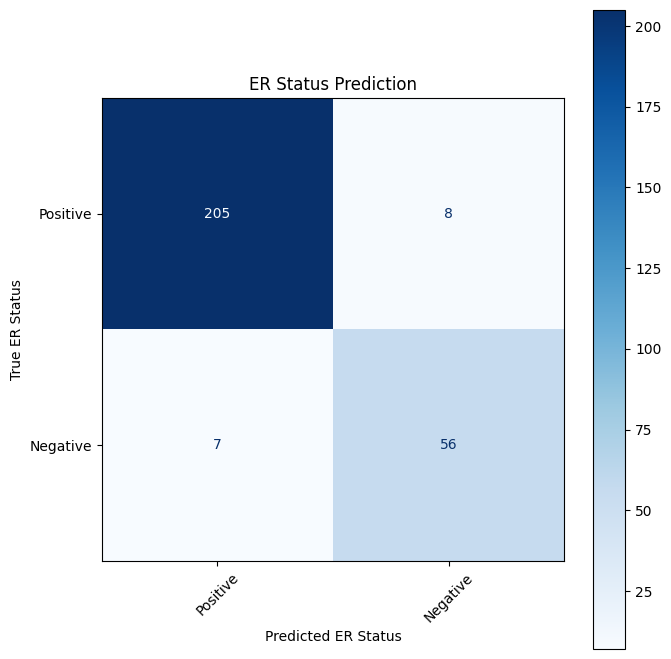

In [321]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

ax.set_title("ER Status Prediction")
ax.set_xlabel("Predicted ER Status")
ax.set_ylabel("True ER Status")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()

fig.savefig(
    "ER_status_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
disp

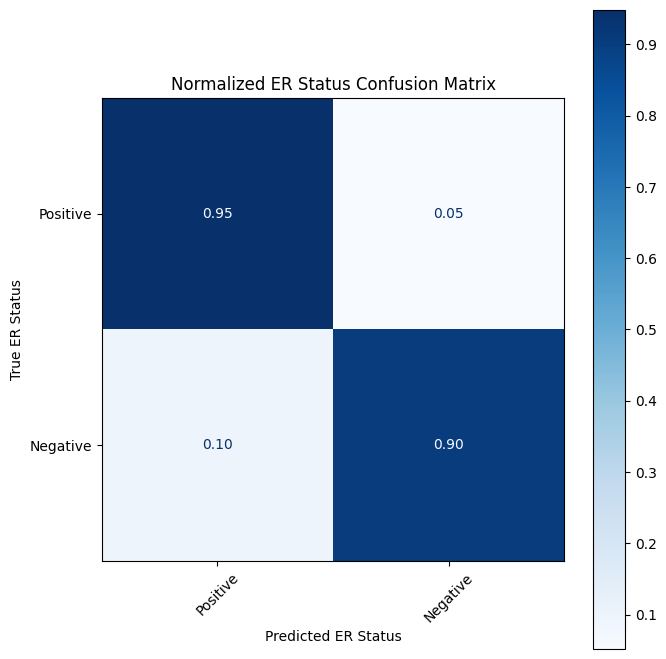

In [138]:
cm_normalized = confusion_matrix(
    y_test,
    predicted_class,
    labels=[0, 1],
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    values_format=".2f",
    cmap="Blues"
)

plt.title("Normalized ER Status Confusion Matrix")
plt.xlabel("Predicted ER Status")
plt.ylabel("True ER Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [337]:
disp

In [338]:
cm_normalized

array([[0.94835681, 0.05164319],
       [0.12698413, 0.87301587]])

In [142]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score

model_full.eval()

# Original predictions
with torch.no_grad():
    logits = model_full(X_test_tensor)
    probability = torch.softmax(logits, dim=1).cpu().numpy()

# IMPORTANT: binary ROC-AUC uses probability of class 1
baseline_auc = roc_auc_score(
    y_test,
    probability[:, 1]
)

print("Baseline ROC-AUC:", baseline_auc)

importance = []

for gene in X_test.columns:

    # Copy test data
    X_perm = X_test.copy()

    # Shuffle one gene
    X_perm[gene] = np.random.permutation(
        X_perm[gene].values
    )

    # Convert to tensor
    X_perm_tensor = torch.tensor(
        X_perm.values,
        dtype=torch.float32
    )

    # Prediction after permutation
    with torch.no_grad():
        logits = model_full(X_perm_tensor)
        prob = torch.softmax(logits, dim=1).cpu().numpy()

    # Binary ROC-AUC using class-1 probability
    perm_auc = roc_auc_score(
        y_test,
        prob[:, 1]
    )

    importance.append({
        "gene": gene,
        "baseline_auc": baseline_auc,
        "permuted_auc": perm_auc,
        "importance": baseline_auc - perm_auc
    })

importance_df = pd.DataFrame(importance)

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(30))

Baseline ROC-AUC: 0.9389671361502347
                    gene  baseline_auc  permuted_auc  importance
0     ENSG00000000003.15      0.938967           0.5    0.438967
2536  ENSG00000169248.13      0.938967           0.5    0.438967
2524  ENSG00000168994.14      0.938967           0.5    0.438967
2525  ENSG00000169026.13      0.938967           0.5    0.438967
2526  ENSG00000169035.12      0.938967           0.5    0.438967
2527   ENSG00000169047.5      0.938967           0.5    0.438967
2528  ENSG00000169071.15      0.938967           0.5    0.438967
2529  ENSG00000169083.18      0.938967           0.5    0.438967
2530  ENSG00000169116.11      0.938967           0.5    0.438967
2531  ENSG00000169122.11      0.938967           0.5    0.438967
2532  ENSG00000169129.15      0.938967           0.5    0.438967
2533   ENSG00000169184.6      0.938967           0.5    0.438967
2534   ENSG00000169213.7      0.938967           0.5    0.438967
2535   ENSG00000169245.6      0.938967           0.5 

In [167]:
importance_df

,gene,baseline_auc,permuted_auc,importance
0,ENSG00000000003.15,0.938967,0.5,0.438967
2536,ENSG00000169248.13,0.938967,0.5,0.438967
2524,ENSG00000168994.14,0.938967,0.5,0.438967
2525,ENSG00000169026.13,0.938967,0.5,0.438967
2526,ENSG00000169035.12,0.938967,0.5,0.438967
...,...,...,...,...
1268,ENSG00000130829.18,0.938967,0.5,0.438967
1269,ENSG00000131016.17,0.938967,0.5,0.438967
1270,ENSG00000131037.15,0.938967,0.5,0.438967
1271,ENSG00000131153.9,0.938967,0.5,0.438967


In [168]:
gene = X_test.columns[0]

X_perm = X_test.copy()
X_perm[gene] = np.random.permutation(X_perm[gene].values)

X_perm_tensor = torch.tensor(
    X_perm.values,
    dtype=torch.float32
)

model_full.eval()

with torch.no_grad():
    logits = model_full(X_perm_tensor)
    prob = torch.softmax(logits, dim=1).cpu().numpy()

print("probability shape:", prob.shape)
print("probability min:", prob.min())
print("probability max:", prob.max())
print("probability mean by class:", prob.mean(axis=0))

print(
    "AUC:",
    roc_auc_score(
        y_test,
        prob[:, 1]
    )
)

probability shape: (276, 4)
probability min: 0.0
probability max: 1.0
probability mean by class: [1. 0. 0. 0.]
AUC: 0.5


In [169]:
with torch.no_grad():
    logits = model_full(X_test_tensor)
    probability = torch.softmax(logits, dim=1).cpu().numpy()

print("Original probability mean by class:",
      probability.mean(axis=0))

print(
    "Original AUC:",
    roc_auc_score(
        y_test,
        probability[:, 1]
    )
)

Original probability mean by class: [7.6319420e-01 2.3644516e-01 1.6896540e-04 1.9167106e-04]
Original AUC: 0.9403830389745882


In [170]:
# model is extremely overconfident and/or has learned a very brittle representation.
#Let's check whether this is happening for every gene or just particular genes.

#Run this on 10 randomly selected genes:

In [171]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score

model_full.eval()

# -----------------------------
# Baseline predictions
# -----------------------------
with torch.no_grad():
    logits = model_full(X_test_tensor)

    probability = torch.softmax(
        logits,
        dim=1
    ).cpu().numpy()

# Probability of positive class
probability_positive = probability[:, 1]

baseline_auc = roc_auc_score(
    y_test,
    probability_positive
)

print("Original AUC:", baseline_auc)

# -----------------------------
# Permutation importance
# -----------------------------
importance = []

for gene in X_test.columns:

    # Copy test data
    X_perm = X_test.copy()

    # Shuffle one gene
    X_perm[gene] = np.random.permutation(
        X_perm[gene].values
    )

    # Convert to tensor
    X_perm_tensor = torch.tensor(
        X_perm.values,
        dtype=torch.float32
    )

    # Prediction
    with torch.no_grad():

        logits_perm = model_full(
            X_perm_tensor
        )

        prob_perm = torch.softmax(
            logits_perm,
            dim=1
        ).cpu().numpy()

    # IMPORTANT:
    # Use probability of class 1 only
    auc_perm = roc_auc_score(
        y_test,
        prob_perm[:, 1]
    )

    importance.append({
        "gene": gene,
        "baseline_auc": baseline_auc,
        "permuted_auc": auc_perm,
        "importance": baseline_auc - auc_perm
    })


# -----------------------------
# Results
# -----------------------------
importance_df = pd.DataFrame(
    importance
)

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(
    importance_df.head(30)
)

Original AUC: 0.9403830389745882
                    gene  baseline_auc  permuted_auc  importance
0     ENSG00000000003.15      0.940383           0.5    0.440383
2536  ENSG00000169248.13      0.940383           0.5    0.440383
2524  ENSG00000168994.14      0.940383           0.5    0.440383
2525  ENSG00000169026.13      0.940383           0.5    0.440383
2526  ENSG00000169035.12      0.940383           0.5    0.440383
2527   ENSG00000169047.5      0.940383           0.5    0.440383
2528  ENSG00000169071.15      0.940383           0.5    0.440383
2529  ENSG00000169083.18      0.940383           0.5    0.440383
2530  ENSG00000169116.11      0.940383           0.5    0.440383
2531  ENSG00000169122.11      0.940383           0.5    0.440383
2532  ENSG00000169129.15      0.940383           0.5    0.440383
2533   ENSG00000169184.6      0.940383           0.5    0.440383
2534   ENSG00000169213.7      0.940383           0.5    0.440383
2535   ENSG00000169245.6      0.940383           0.5    0

In [172]:
print(X_test.iloc[:, :10].describe().loc[["mean", "std", "min", "max"]])

      ENSG00000000003.15  ENSG00000000971.16  ENSG00000001561.7  \
mean           11.232780           11.329475          10.613526   
std             0.973666            0.925665           0.939890   
min             8.113721            7.656237           7.914724   
max            13.608115           14.289439          13.688549   

      ENSG00000001617.12  ENSG00000002586.20  ENSG00000002726.21  \
mean           12.481304           13.232466            7.876524   
std             0.896416            0.840915            0.959484   
min             9.918676           10.435865            6.807847   
max            14.753207           16.026131           13.912321   

      ENSG00000002933.9  ENSG00000003096.14  ENSG00000003249.15  \
mean          10.962846            8.950029           11.186632   
std            1.153427            1.004481            0.923241   
min            7.973101            7.301442            8.153854   
max           14.455109           12.534180           1

In [173]:
print(
    "Overall min:",
    X_test.min().min()
)

print(
    "Overall max:",
    X_test.max().max()
)

Overall min: 6.80784699137843
Overall max: 22.9204791630282


In [404]:
print(X_train.shape)
print(X_test.shape)

print("\nX_train first 5 genes:")
print(X_train.iloc[:, :5].mean())
print(X_train.iloc[:, :5].std())

print("\nX_test first 5 genes:")
print(X_test.iloc[:, :5].mean())
print(X_test.iloc[:, :5].std())

(643, 3796)
(276, 3796)

X_train first 5 genes:
ENSG00000000003.15    11.428239
ENSG00000000971.16    11.376457
ENSG00000001561.7     10.688288
ENSG00000001617.12    12.456450
ENSG00000002586.20    13.219355
dtype: float64
ENSG00000000003.15    0.910150
ENSG00000000971.16    0.985470
ENSG00000001561.7     0.958916
ENSG00000001617.12    0.842382
ENSG00000002586.20    0.843373
dtype: float64

X_test first 5 genes:
ENSG00000000003.15    11.232780
ENSG00000000971.16    11.329475
ENSG00000001561.7     10.613526
ENSG00000001617.12    12.481304
ENSG00000002586.20    13.232466
dtype: float64
ENSG00000000003.15    0.973666
ENSG00000000971.16    0.925665
ENSG00000001561.7     0.939890
ENSG00000001617.12    0.896416
ENSG00000002586.20    0.840915
dtype: float64


In [175]:
model_full.eval()

with torch.no_grad():
    logits = model_full(X_test_tensor)

print("First 10 logits:")
print(logits[:10])

print("\nMean logits:")
print(logits.mean(dim=0))

print("\nSD logits:")
print(logits.std(dim=0))

print("\nMin/max logits:")
print(logits.min().item(), logits.max().item())

First 10 logits:
tensor([[ 6.5249, -0.1698, -0.9443, -0.2065],
        [20.5722, -3.9054, -4.8542, -3.9821],
        [ 0.9569, 11.3549, -6.0205, -3.2142],
        [ 1.5988, 10.5726, -6.0923, -2.9972],
        [11.9717, -0.6322, -2.5420, -1.8585],
        [17.5003, -2.5837, -3.6689, -1.5102],
        [ 7.1899,  4.6053, -4.8592, -3.0769],
        [-0.1426, 10.7729, -6.0454, -3.3495],
        [ 9.3929, -0.1029, -1.5775, -0.1756],
        [14.0294, -1.7916, -1.7982,  1.1185]])

Mean logits:
tensor([13.0131,  0.8821, -4.6860, -2.7554])

SD logits:
tensor([8.0915, 5.5254, 1.8936, 1.4764])

Min/max logits:
-10.90715217590332 32.71037292480469


In [176]:
print("Training predictions:")

model_full.eval()

with torch.no_grad():
    train_logits = model_full(X_train_tensor)
    train_prob = torch.softmax(train_logits, dim=1).cpu().numpy()

train_pred = np.argmax(train_prob, axis=1)

print(
    classification_report(
        y_train,
        train_pred,
        labels=[0, 1],
        target_names=[
            "Positive",
            "Negative"
        ],
        zero_division=0
    )
)

Training predictions:
              precision    recall  f1-score   support

    Positive       1.00      1.00      1.00       496
    Negative       1.00      1.00      1.00       147

    accuracy                           1.00       643
   macro avg       1.00      1.00      1.00       643
weighted avg       1.00      1.00      1.00       643



In [350]:
## DOing prediction with a smaller set of genes

In [177]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

In [178]:
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, input_dim, n_classes=4):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        return self.network(x)

In [179]:
#Defining MLP 

In [180]:
model_full = MLP(
    input_dim=X_train.shape[1],
    n_classes=4
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_full.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [181]:
n_epochs = 100

for epoch in range(n_epochs):

    model_full.train()

    optimizer.zero_grad()

    logits = model_full(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"Loss: {loss.item():.4f}"
        )

Epoch 10/100, Loss: 0.3214
Epoch 20/100, Loss: 0.1747
Epoch 30/100, Loss: 0.0937
Epoch 40/100, Loss: 0.0438
Epoch 50/100, Loss: 0.0410
Epoch 60/100, Loss: 0.0125
Epoch 70/100, Loss: 0.0081
Epoch 80/100, Loss: 0.0087
Epoch 90/100, Loss: 0.0056
Epoch 100/100, Loss: 0.0062


In [182]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

model_full.eval()

with torch.no_grad():

    logits = model_full(X_test_tensor)

    probability = torch.softmax(
        logits,
        dim=1
    ).cpu().numpy()

predicted_class = np.argmax(
    probability,
    axis=1
)


In [183]:
# Probability of class 1
probability_positive = probability[:, 1]

roc_auc = roc_auc_score(
    y_test,
    probability_positive
)

accuracy = accuracy_score(
    y_test,
    predicted_class
)

print("ROC-AUC:", roc_auc)
print("Accuracy:", accuracy)

print(
    classification_report(
        y_test,
        predicted_class
    )
)

print(
    confusion_matrix(
        y_test,
        predicted_class
    )
)

ROC-AUC: 0.9408674267829197
Accuracy: 0.9347826086956522
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       213
           1       0.85      0.87      0.86        63

    accuracy                           0.93       276
   macro avg       0.90      0.91      0.91       276
weighted avg       0.94      0.93      0.94       276

[[203  10]
 [  8  55]]


In [358]:
#permutation importance - machine learning technique that measures how much a trained model relies on a specific feature 
#by observing how much the model's performance drops when that feature's values are randomly shuffled

In [360]:
# check what the model is doing after one permutation
## running repeated permutation

In [394]:
#The repeated permutation analysis shows that the individual-gene effects are consistently very small.

In [395]:
## "How many genes are required to maintain the model's predictive performance?"

In [184]:
importance_df

,gene,baseline_auc,permuted_auc,importance
0,ENSG00000000003.15,0.940383,0.5,0.440383
2536,ENSG00000169248.13,0.940383,0.5,0.440383
2524,ENSG00000168994.14,0.940383,0.5,0.440383
2525,ENSG00000169026.13,0.940383,0.5,0.440383
2526,ENSG00000169035.12,0.940383,0.5,0.440383
...,...,...,...,...
1268,ENSG00000130829.18,0.940383,0.5,0.440383
1269,ENSG00000131016.17,0.940383,0.5,0.440383
1270,ENSG00000131037.15,0.940383,0.5,0.440383
1271,ENSG00000131153.9,0.940383,0.5,0.440383


In [367]:
## create a validation set as well

In [405]:
from sklearn.model_selection import train_test_split

X_train_dev, X_val, y_train_dev, y_val = train_test_split(
    X_train,
    y_train_original,
    test_size=0.20,
    stratify=y_train_original,
    random_state=42
)

In [406]:
print("=== Data dimensions ===")

print("X_train_dev:")
print("  shape:", X_train_dev.shape)

print("X_val:")
print("  shape:", X_val.shape)

print("X_test:")
print("  shape:", X_test.shape)

print("\ny_train_dev:")
print("  shape:", np.asarray(y_train_dev).shape)

print("y_val:")
print("  shape:", np.asarray(y_val).shape)

print("y_test_original:")
print("  shape:", np.asarray(y_test_original).shape)


print("\n=== Expected dimensions ===")

print("X_train_dev  :", (514, 3796))
print("X_val        :", (129, 3796))
print("X_test       :", (276, 3796))
print("y_train_dev  :", (514,))
print("y_val        :", (129,))
print("y_test       :", (276,))


print("\n=== Dimension checks ===")

assert X_train_dev.shape == (514, 3796)
assert X_val.shape == (129, 3796)
assert X_test.shape == (276, 3796)

assert np.asarray(y_train_dev).shape == (514,)
assert np.asarray(y_val).shape == (129,)
assert np.asarray(y_test_original).shape == (276,)

print("All dimensions are correct.")

=== Data dimensions ===
X_train_dev:
  shape: (514, 3796)
X_val:
  shape: (129, 3796)
X_test:
  shape: (276, 3796)

y_train_dev:
  shape: (514,)
y_val:
  shape: (129,)
y_test_original:
  shape: (276,)

=== Expected dimensions ===
X_train_dev  : (514, 3796)
X_val        : (129, 3796)
X_test       : (276, 3796)
y_train_dev  : (514,)
y_val        : (129,)
y_test       : (276,)

=== Dimension checks ===
All dimensions are correct.


In [407]:
print("\n=== Sample-count consistency ===")

print("Train:", X_train_dev.shape[0], len(y_train_dev))
print("Val:  ", X_val.shape[0], len(y_val))
print("Test: ", X_test.shape[0], len(y_test_original))

assert X_train_dev.shape[0] == len(y_train_dev)
assert X_val.shape[0] == len(y_val)
assert X_test.shape[0] == len(y_test_original)

print("Train/validation/test sample counts match.")


=== Sample-count consistency ===
Train: 514 514
Val:   129 129
Test:  276 276
Train/validation/test sample counts match.


In [205]:
X_train_dev

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,ENSG00000286619.1,ENSG00000287151.1,ENSG00000287262.1,ENSG00000287550.1,ENSG00000287609.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287900.1,ENSG00000287914.1,ENSG00000287952.1
TCGA-D8-A1XU,12.087093,11.574924,10.948147,11.557019,13.662347,7.411354,10.184560,9.019356,10.867664,9.577276,...,8.768948,10.327394,7.886279,8.308860,6.973211,10.505059,7.315193,9.585782,9.999655,9.333649
TCGA-AN-A0AK,8.427107,10.666840,10.630667,12.573380,11.706701,7.816681,10.391955,7.422358,11.948525,9.638563,...,7.489650,8.307265,8.158654,8.235487,6.807847,7.231073,7.107647,8.792474,8.307265,8.129281
TCGA-E9-A1N4,9.188291,12.346272,11.820105,12.089566,13.219831,7.601825,10.889009,8.897237,9.077614,10.886500,...,6.807847,9.019566,11.486346,7.234039,6.963961,8.094671,7.204801,7.311400,7.828353,7.788935
TCGA-E9-A5FL,11.174119,13.181954,9.500510,13.918062,14.333478,10.496055,11.287326,8.396784,11.829419,10.479591,...,9.143748,8.154803,7.674128,6.807847,7.124795,7.124795,7.924811,6.807847,6.991082,6.807847
TCGA-BH-A1EX,12.393158,12.413721,10.456138,11.622308,13.341463,7.546501,10.987215,7.629867,12.958906,9.719765,...,7.144430,8.586412,8.341829,7.756668,6.914501,7.046116,7.561098,8.685331,7.416151,6.807847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AC-A2FB,11.974379,11.720023,11.330946,12.881397,12.771731,8.340961,10.941644,10.335140,10.572742,10.945973,...,8.275289,8.238613,8.438742,8.871320,7.087028,8.016413,7.221171,6.807847,7.993057,8.252510
TCGA-C8-A134,11.200962,11.276716,10.804283,11.220963,12.880536,7.859278,12.186644,9.545340,12.085863,9.440977,...,7.078595,7.762573,7.693178,6.952720,7.252796,7.161970,10.697845,6.910309,6.910309,6.952720
TCGA-A8-A07G,11.513897,11.796537,10.072755,11.524299,14.279535,7.923689,10.659117,8.607242,10.098744,9.721039,...,9.043844,9.229346,11.025473,9.878767,6.988589,10.432953,7.501613,6.807847,9.274619,8.099464
TCGA-E9-A22G,12.542211,10.359186,10.234638,10.927760,12.977092,8.205947,10.168545,12.088685,10.396256,9.358478,...,7.739525,7.477964,7.430793,7.139316,7.985710,7.337569,10.851349,6.807847,6.933367,6.933367


In [206]:
from sklearn.preprocessing import StandardScaler
import torch
import numpy as np

scaler_full = StandardScaler()

X_train_full_scaled = scaler_full.fit_transform(
    X_train_dev
)

X_val_full_scaled = scaler_full.transform(
    X_val
)

X_test_full_scaled = scaler_full.transform(
    X_test
)

X_train_full_tensor = torch.tensor(
    X_train_full_scaled,
    dtype=torch.float32
)

X_val_full_tensor = torch.tensor(
    X_val_full_scaled,
    dtype=torch.float32
)

X_test_full_tensor = torch.tensor(
    X_test_full_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    np.asarray(y_train_dev),
    dtype=torch.long
)

In [207]:
print(X_train_full_tensor.shape)
print(X_val_full_tensor.shape)
print(X_test_full_tensor.shape)
print(y_train_tensor.shape)

torch.Size([514, 3796])
torch.Size([129, 3796])
torch.Size([276, 3796])
torch.Size([514])


In [209]:
# Checking dimensions before model training
print("=== Tensor dimensions ===")

print("X_train_full_tensor:", X_train_full_tensor.shape)
#print("X_val_full_tensor:  ", X_val_full_tensor.shape)
print("X_test_full_tensor: ", X_test_full_tensor.shape)
print("y_train_tensor:     ", y_train_tensor.shape)


# Expected dimensions
assert X_train_full_tensor.shape == (514, 3796)
#assert X_val_full_tensor.shape == (129, 3796)
assert X_test_full_tensor.shape == (276, 3796)
assert y_train_tensor.shape == (514,)


# Check that sample numbers match
assert X_train_full_tensor.shape[0] == y_train_tensor.shape[0]
#assert X_val_full_tensor.shape[0] == len(y_val)
assert X_test_full_tensor.shape[0] == len(y_test_original)


print("\nAll dimensions are correct.")
print("Train samples:", X_train_full_tensor.shape[0])
print("Validation samples:", X_val_full_tensor.shape[0])
print("Test samples:", X_test_full_tensor.shape[0])
print("Number of genes:", X_train_full_tensor.shape[1])

=== Tensor dimensions ===
X_train_full_tensor: torch.Size([514, 3796])
X_test_full_tensor:  torch.Size([276, 3796])
y_train_tensor:      torch.Size([514])

All dimensions are correct.
Train samples: 514
Validation samples: 129
Test samples: 276
Number of genes: 3796


In [210]:
def train_mlp(
    X_train_tensor,
    y_train_tensor,
    n_classes=2,
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-4
):
    input_dim = X_train_tensor.shape[1]

    model = MLP(
        input_dim=input_dim,
        n_classes=n_classes
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    for epoch in range(n_epochs):

        model.train()

        optimizer.zero_grad()

        logits = model(X_train_tensor)

        loss = criterion(
            logits,
            y_train_tensor
        )

        loss.backward()

        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1}/{n_epochs}, "
                f"Loss: {loss.item():.4f}"
            )

    return model

In [211]:
model_full_new = train_mlp(
    X_train_full_tensor,
    y_train_tensor,
    n_classes=2
)

Epoch 10/100, Loss: 0.1435
Epoch 20/100, Loss: 0.0691
Epoch 30/100, Loss: 0.0327
Epoch 40/100, Loss: 0.0136
Epoch 50/100, Loss: 0.0103
Epoch 60/100, Loss: 0.0049
Epoch 70/100, Loss: 0.0030
Epoch 80/100, Loss: 0.0019
Epoch 90/100, Loss: 0.0017
Epoch 100/100, Loss: 0.0030


In [212]:
top100_genes = importance_df.head(100)["gene"].tolist()
top200_genes = importance_df.head(200)["gene"].tolist()
top500_genes = importance_df.head(500)["gene"].tolist()

In [369]:
# Subset expression matrices to top genes

In [371]:
# Checking shape of data is consistent

In [176]:
## Performances similar in one single run. Hence running the models for repeatedly to record ROC_AUC for every run
## Will calculate mean and SD for runs of 100, 200 and 500 genes and notice if any meaningful differences
## Additionally check if 200 vs 500 genes meaningfully different
## Will examine statbility of feature selection
## Lock the architecture, gene set and hyperparameters.
## Will train locked model on complete development set
## Evaluate model on test set

In [213]:
model_full_new.eval()

with torch.no_grad():
    logits_train = model_full_new(
        X_train_full_tensor
    )

    probability_train = torch.softmax(
        logits_train,
        dim=1
    ).cpu().numpy()

baseline_auc_train = roc_auc_score(
    y_train_dev,
    probability_train[:, 1]
)

print("Training baseline ROC-AUC:", baseline_auc_train)

Training baseline ROC-AUC: 1.0


In [214]:
print("logits_train:", logits_train.shape)
print("probability_train:", probability_train.shape)
print("y_train_dev:", np.asarray(y_train_dev).shape)

logits_train: torch.Size([514, 2])
probability_train: (514, 2)
y_train_dev: (514,)


In [215]:
# Calculate permutation importance
n_repeats = 30

importance_train = []

for gene_idx, gene in enumerate(X_train_dev.columns):

    auc_drop = []

    for r in range(n_repeats):

        # Copy the TRAINING data
        X_perm = X_train_full_scaled.copy()

        # Permute one gene
        X_perm[:, gene_idx] = np.random.permutation(
            X_perm[:, gene_idx]
        )

        X_perm_tensor = torch.tensor(
            X_perm,
            dtype=torch.float32
        )

        # Predict
        with torch.no_grad():
            logits_perm = model_full_new(
                X_perm_tensor
            )

            prob_perm = torch.softmax(
                logits_perm,
                dim=1
            ).cpu().numpy()

        # Calculate AUC on TRAINING data
        auc_perm = roc_auc_score(
            y_train_dev,
            prob_perm[:, 1]
        )

        auc_drop.append(
            baseline_auc_train - auc_perm
        )

    importance_train.append({
        "gene": gene,
        "mean_importance": np.mean(auc_drop),
        "median_importance": np.median(auc_drop),
        "sd_importance": np.std(auc_drop),
        "min_importance": np.min(auc_drop),
        "max_importance": np.max(auc_drop)
    })

importance_train_df = (
    pd.DataFrame(importance_train)
    .sort_values(
        "mean_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print(importance_train_df.head(30))

                  gene  mean_importance  median_importance  sd_importance  \
0   ENSG00000123453.18     3.700743e-18                0.0   1.992911e-17   
1   ENSG00000000003.15     0.000000e+00                0.0   0.000000e+00   
2   ENSG00000168961.17     0.000000e+00                0.0   0.000000e+00   
3   ENSG00000168994.14     0.000000e+00                0.0   0.000000e+00   
4   ENSG00000169026.13     0.000000e+00                0.0   0.000000e+00   
5   ENSG00000169035.12     0.000000e+00                0.0   0.000000e+00   
6    ENSG00000169047.5     0.000000e+00                0.0   0.000000e+00   
7   ENSG00000169071.15     0.000000e+00                0.0   0.000000e+00   
8   ENSG00000169083.18     0.000000e+00                0.0   0.000000e+00   
9   ENSG00000169116.11     0.000000e+00                0.0   0.000000e+00   
10  ENSG00000169122.11     0.000000e+00                0.0   0.000000e+00   
11  ENSG00000169129.15     0.000000e+00                0.0   0.000000e+00   

In [216]:
print(
    importance_train_df[
        ["gene", "mean_importance", "median_importance", "sd_importance"]
    ].head(30)
)

                  gene  mean_importance  median_importance  sd_importance
0   ENSG00000123453.18     3.700743e-18                0.0   1.992911e-17
1   ENSG00000000003.15     0.000000e+00                0.0   0.000000e+00
2   ENSG00000168961.17     0.000000e+00                0.0   0.000000e+00
3   ENSG00000168994.14     0.000000e+00                0.0   0.000000e+00
4   ENSG00000169026.13     0.000000e+00                0.0   0.000000e+00
5   ENSG00000169035.12     0.000000e+00                0.0   0.000000e+00
6    ENSG00000169047.5     0.000000e+00                0.0   0.000000e+00
7   ENSG00000169071.15     0.000000e+00                0.0   0.000000e+00
8   ENSG00000169083.18     0.000000e+00                0.0   0.000000e+00
9   ENSG00000169116.11     0.000000e+00                0.0   0.000000e+00
10  ENSG00000169122.11     0.000000e+00                0.0   0.000000e+00
11  ENSG00000169129.15     0.000000e+00                0.0   0.000000e+00
12   ENSG00000169184.6     0.000000e+0

In [217]:
#5-fold out-of-fold permutation importance due to all importance being 0

In [218]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

In [219]:
# --------------------------------------------------
# 5-fold out-of-fold permutation importance
# --------------------------------------------------

n_splits = 5
n_repeats = 10

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

genes = X_train_dev.columns.tolist()

importance_records = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train_dev, y_train_dev),
    start=1
):

    print(f"\n===== Fold {fold}/{n_splits} =====")

    # ----------------------------------------------
    # Split development data into fold train/holdout
    # ----------------------------------------------

    X_fold_train = X_train_dev.iloc[train_idx]
    X_fold_val = X_train_dev.iloc[val_idx]

    y_fold_train = np.asarray(y_train_dev)[train_idx]
    y_fold_val = np.asarray(y_train_dev)[val_idx]


    # ----------------------------------------------
    # Scale using fold-training data ONLY
    # ----------------------------------------------

    scaler = StandardScaler()

    X_fold_train_scaled = scaler.fit_transform(
        X_fold_train
    )

    X_fold_val_scaled = scaler.transform(
        X_fold_val
    )


    # ----------------------------------------------
    # Convert to tensors
    # ----------------------------------------------

    X_fold_train_tensor = torch.tensor(
        X_fold_train_scaled,
        dtype=torch.float32
    )

    X_fold_val_tensor = torch.tensor(
        X_fold_val_scaled,
        dtype=torch.float32
    )

    y_fold_train_tensor = torch.tensor(
        y_fold_train,
        dtype=torch.long
    )


    # ----------------------------------------------
    # Train MLP
    # ----------------------------------------------

    torch.manual_seed(42 + fold)

    model_fold = train_mlp(
        X_fold_train_tensor,
        y_fold_train_tensor,
        n_classes=2
    )


    # ----------------------------------------------
    # Baseline prediction on held-out fold
    # ----------------------------------------------

    model_fold.eval()

    with torch.no_grad():

        logits_val = model_fold(
            X_fold_val_tensor
        )

        probability_val = torch.softmax(
            logits_val,
            dim=1
        ).cpu().numpy()


    baseline_auc = roc_auc_score(
        y_fold_val,
        probability_val[:, 1]
    )

    print(
        f"Fold {fold} baseline AUC: "
        f"{baseline_auc:.4f}"
    )


    # ----------------------------------------------
    # Permutation importance
    # ----------------------------------------------

    for gene_idx, gene in enumerate(genes):

        auc_drops = []

        for r in range(n_repeats):

            # Copy held-out fold
            X_perm = X_fold_val_scaled.copy()

            # Permute ONE gene among held-out samples
            rng = np.random.default_rng(
                1000 + fold * 100 + r
            )

            X_perm[:, gene_idx] = rng.permutation(
                X_perm[:, gene_idx]
            )


            # Convert to tensor
            X_perm_tensor = torch.tensor(
                X_perm,
                dtype=torch.float32
            )


            # Prediction after permutation
            with torch.no_grad():

                logits_perm = model_fold(
                    X_perm_tensor
                )

                probability_perm = torch.softmax(
                    logits_perm,
                    dim=1
                ).cpu().numpy()


            # Permuted AUC
            auc_perm = roc_auc_score(
                y_fold_val,
                probability_perm[:, 1]
            )


            # AUC decrease
            auc_drop = (
                baseline_auc -
                auc_perm
            )

            auc_drops.append(auc_drop)


        # Store results for this gene/fold
        importance_records.append({
            "fold": fold,
            "gene": gene,
            "mean_importance": np.mean(auc_drops),
            "median_importance": np.median(auc_drops),
            "sd_importance": np.std(auc_drops)
        })


    print(
        f"Completed permutation importance "
        f"for fold {fold}"
    )


===== Fold 1/5 =====
Epoch 10/100, Loss: 0.1566
Epoch 20/100, Loss: 0.0743
Epoch 30/100, Loss: 0.0293
Epoch 40/100, Loss: 0.0144
Epoch 50/100, Loss: 0.0069
Epoch 60/100, Loss: 0.0027
Epoch 70/100, Loss: 0.0028
Epoch 80/100, Loss: 0.0015
Epoch 90/100, Loss: 0.0013
Epoch 100/100, Loss: 0.0016
Fold 1 baseline AUC: 0.9375
Completed permutation importance for fold 1

===== Fold 2/5 =====
Epoch 10/100, Loss: 0.1437
Epoch 20/100, Loss: 0.0770
Epoch 30/100, Loss: 0.0243
Epoch 40/100, Loss: 0.0119
Epoch 50/100, Loss: 0.0089
Epoch 60/100, Loss: 0.0027
Epoch 70/100, Loss: 0.0015
Epoch 80/100, Loss: 0.0020
Epoch 90/100, Loss: 0.0006
Epoch 100/100, Loss: 0.0004
Fold 2 baseline AUC: 0.9211
Completed permutation importance for fold 2

===== Fold 3/5 =====
Epoch 10/100, Loss: 0.1488
Epoch 20/100, Loss: 0.0549
Epoch 30/100, Loss: 0.0268
Epoch 40/100, Loss: 0.0139
Epoch 50/100, Loss: 0.0067
Epoch 60/100, Loss: 0.0052
Epoch 70/100, Loss: 0.0037
Epoch 80/100, Loss: 0.0040
Epoch 90/100, Loss: 0.0036
Epoch

In [221]:
# Combining 5 folds
importance_oof_df = pd.DataFrame(
    importance_records
)

print(importance_oof_df.shape)

(18980, 5)


In [222]:
## Aggregating across 5 folds
importance_oof_summary = (
    importance_oof_df
    .groupby("gene")
    .agg(
        mean_importance=(
            "mean_importance",
            "mean"
        ),
        median_importance=(
            "mean_importance",
            "median"
        ),
        sd_importance=(
            "mean_importance",
            "std"
        ),
        mean_fold_median=(
            "median_importance",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "mean_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

In [223]:
print(
    importance_oof_summary[
        [
            "gene",
            "mean_importance",
            "median_importance",
            "sd_importance"
        ]
    ].head(30)
)

                  gene  mean_importance  median_importance  sd_importance
0    ENSG00000211968.3         0.000176       1.318565e-04       0.000327
1   ENSG00000108309.14         0.000164       2.751789e-05       0.000229
2   ENSG00000124493.14         0.000154       1.630435e-04       0.000327
3    ENSG00000233622.3         0.000154       1.582278e-04       0.000345
4   ENSG00000249859.12         0.000153      -2.220446e-17       0.000392
5    ENSG00000138650.9         0.000151       5.274262e-05       0.000208
6   ENSG00000055163.20         0.000145       3.691983e-04       0.000465
7    ENSG00000256612.7         0.000144       1.582278e-04       0.000317
8   ENSG00000186665.10         0.000132       0.000000e+00       0.000529
9    ENSG00000211942.3         0.000118       7.911392e-05       0.000258
10  ENSG00000111846.19         0.000117       1.630435e-04       0.000320
11  ENSG00000018408.15         0.000117       0.000000e+00       0.000206
12   ENSG00000203867.8         0.00011

In [224]:
print(
    importance_oof_summary["mean_importance"].describe()
)

count    3796.000000
mean       -0.000119
std         0.000071
min        -0.000436
25%        -0.000161
50%        -0.000116
75%        -0.000074
max         0.000176
Name: mean_importance, dtype: float64


In [225]:
print(
    "Number of genes with positive importance:",
    (
        importance_oof_summary["mean_importance"] > 0
    ).sum()
)

print(
    "Number of genes with negative importance:",
    (
        importance_oof_summary["mean_importance"] < 0
    ).sum()
)

print(
    "Number of genes with zero importance:",
    (
        importance_oof_summary["mean_importance"] == 0
    ).sum()
)

Number of genes with positive importance: 116
Number of genes with negative importance: 3677
Number of genes with zero importance: 3


In [226]:
top100_genes = (
    importance_oof_summary
    .head(100)["gene"]
    .tolist()
)

top200_genes = (
    importance_oof_summary
    .head(200)["gene"]
    .tolist()
)

top500_genes = (
    importance_oof_summary
    .head(500)["gene"]
    .tolist()
)

In [227]:
print(
    importance_oof_summary[
        [
            "gene",
            "mean_importance",
            "median_importance",
            "sd_importance"
        ]
    ].head(30)
)

                  gene  mean_importance  median_importance  sd_importance
0    ENSG00000211968.3         0.000176       1.318565e-04       0.000327
1   ENSG00000108309.14         0.000164       2.751789e-05       0.000229
2   ENSG00000124493.14         0.000154       1.630435e-04       0.000327
3    ENSG00000233622.3         0.000154       1.582278e-04       0.000345
4   ENSG00000249859.12         0.000153      -2.220446e-17       0.000392
5    ENSG00000138650.9         0.000151       5.274262e-05       0.000208
6   ENSG00000055163.20         0.000145       3.691983e-04       0.000465
7    ENSG00000256612.7         0.000144       1.582278e-04       0.000317
8   ENSG00000186665.10         0.000132       0.000000e+00       0.000529
9    ENSG00000211942.3         0.000118       7.911392e-05       0.000258
10  ENSG00000111846.19         0.000117       1.630435e-04       0.000320
11  ENSG00000018408.15         0.000117       0.000000e+00       0.000206
12   ENSG00000203867.8         0.00011

In [228]:
print(
    importance_oof_summary["mean_importance"].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

count    3796.000000
mean       -0.000119
std         0.000071
min        -0.000436
1%         -0.000301
5%         -0.000243
25%        -0.000161
50%        -0.000116
75%        -0.000074
95%        -0.000011
99%         0.000042
max         0.000176
Name: mean_importance, dtype: float64


In [229]:
print(
    "Maximum importance:",
    importance_oof_summary["mean_importance"].max()
)

print(
    "Minimum importance:",
    importance_oof_summary["mean_importance"].min()
)

Maximum importance: 0.00017611447440837093
Minimum importance: -0.0004362502293157


In [230]:
fold_auc_values = [
    0.9375,
    0.9211,
    0.9531,
    0.9488,
    0.9271
]

print(
    "Mean OOF AUC:",
    np.mean(fold_auc_values)
)

print(
    "SD OOF AUC:",
    np.std(fold_auc_values, ddof=1)
)

Mean OOF AUC: 0.9375199999999999
SD OOF AUC: 0.01367632991705008


In [231]:
## create feature set of top 100, 200, 500 genes

In [232]:
top100_genes = (
    importance_oof_summary
    .head(100)["gene"]
    .tolist()
)

top200_genes = (
    importance_oof_summary
    .head(200)["gene"]
    .tolist()
)

top500_genes = (
    importance_oof_summary
    .head(500)["gene"]
    .tolist()
)

In [233]:
print("100 genes:", len(top100_genes))
print("200 genes:", len(top200_genes))
print("500 genes:", len(top500_genes))

100 genes: 100
200 genes: 200
500 genes: 500


In [234]:
## train 100 gene model
from sklearn.preprocessing import StandardScaler

# Select genes
X_train_100 = X_train_dev[top100_genes]
X_val_100 = X_val[top100_genes]

# Scale using training data only
scaler_100 = StandardScaler()

X_train_100_scaled = scaler_100.fit_transform(
    X_train_100
)

X_val_100_scaled = scaler_100.transform(
    X_val_100
)

# Convert to tensors
X_train_100_tensor = torch.tensor(
    X_train_100_scaled,
    dtype=torch.float32
)

X_val_100_tensor = torch.tensor(
    X_val_100_scaled,
    dtype=torch.float32
)

# Labels
y_train_tensor = torch.tensor(
    np.asarray(y_train_dev),
    dtype=torch.long
)

In [235]:
## train 200 gene model
from sklearn.preprocessing import StandardScaler

# Select genes
X_train_200 = X_train_dev[top200_genes]
X_val_200 = X_val[top200_genes]

# Scale using training data only
scaler_200 = StandardScaler()

X_train_200_scaled = scaler_200.fit_transform(
    X_train_200
)

X_val_200_scaled = scaler_200.transform(
    X_val_200
)

# Convert to tensors
X_train_200_tensor = torch.tensor(
    X_train_200_scaled,
    dtype=torch.float32
)

X_val_200_tensor = torch.tensor(
    X_val_200_scaled,
    dtype=torch.float32
)

# Labels
y_train_tensor = torch.tensor(
    np.asarray(y_train_dev),
    dtype=torch.long
)

In [236]:
## train 500 gene model
from sklearn.preprocessing import StandardScaler

# Select genes
X_train_500 = X_train_dev[top500_genes]
X_val_500 = X_val[top500_genes]

# Scale using training data only
scaler_500 = StandardScaler()

X_train_500_scaled = scaler_500.fit_transform(
    X_train_500
)

X_val_500_scaled = scaler_500.transform(
    X_val_500
)

# Convert to tensors
X_train_500_tensor = torch.tensor(
    X_train_500_scaled,
    dtype=torch.float32
)

X_val_500_tensor = torch.tensor(
    X_val_500_scaled,
    dtype=torch.float32
)

# Labels
y_train_tensor = torch.tensor(
    np.asarray(y_train_dev),
    dtype=torch.long
)

In [237]:
model_100 = train_mlp(
    X_train_100_tensor,
    y_train_tensor,
    n_classes=2
)


model_200 = train_mlp(
    X_train_200_tensor,
    y_train_tensor,
    n_classes=2
)

model_500 = train_mlp(
    X_train_500_tensor,
    y_train_tensor,
    n_classes=2
)


Epoch 10/100, Loss: 0.4424
Epoch 20/100, Loss: 0.2818
Epoch 30/100, Loss: 0.2023
Epoch 40/100, Loss: 0.1680
Epoch 50/100, Loss: 0.1332
Epoch 60/100, Loss: 0.0985
Epoch 70/100, Loss: 0.0872
Epoch 80/100, Loss: 0.0669
Epoch 90/100, Loss: 0.0639
Epoch 100/100, Loss: 0.0412
Epoch 10/100, Loss: 0.4183
Epoch 20/100, Loss: 0.2284
Epoch 30/100, Loss: 0.1638
Epoch 40/100, Loss: 0.1274
Epoch 50/100, Loss: 0.0927
Epoch 60/100, Loss: 0.0717
Epoch 70/100, Loss: 0.0572
Epoch 80/100, Loss: 0.0367
Epoch 90/100, Loss: 0.0250
Epoch 100/100, Loss: 0.0152
Epoch 10/100, Loss: 0.3406
Epoch 20/100, Loss: 0.1954
Epoch 30/100, Loss: 0.1287
Epoch 40/100, Loss: 0.1011
Epoch 50/100, Loss: 0.0654
Epoch 60/100, Loss: 0.0316
Epoch 70/100, Loss: 0.0205
Epoch 80/100, Loss: 0.0117
Epoch 90/100, Loss: 0.0047
Epoch 100/100, Loss: 0.0030


In [239]:
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
import torch

def evaluate_auc(model, X_tensor, y):

    model.eval()

    with torch.no_grad():

        logits = model(X_tensor)

        probability = torch.softmax(
            logits,
            dim=1
        ).cpu().numpy()

    auc = roc_auc_score(
        np.asarray(y),
        probability[:, 1]
    )

    accuracy = accuracy_score(
        np.asarray(y),
        np.argmax(probability, axis=1)
    )

    return auc, accuracy

In [240]:
auc_100, accuracy_100 = evaluate_auc(
    model_100,
    X_val_100_tensor,
    y_val
)

print("100-gene validation AUC:", auc_100)
print("100-gene validation accuracy:", accuracy_100)

100-gene validation AUC: 0.9620689655172414
100-gene validation accuracy: 0.9224806201550387


In [ ]:
#evaluate model on validation set


In [241]:
auc_100, accuracy_100 = evaluate_auc(
    model_100,
    X_val_100_tensor,
    y_val
)

auc_200, accuracy_200 = evaluate_auc(
    model_200,
    X_val_200_tensor,
    y_val
)

auc_500, accuracy_500 = evaluate_auc(
    model_500,
    X_val_500_tensor,
    y_val
)

In [242]:
print("100-gene validation AUC:", auc_100)
print("100-gene validation accuracy:", accuracy_100)

print("200-gene validation AUC:", auc_200)
print("200-gene validation accuracy:", accuracy_200)

print("500-gene validation AUC:", auc_500)
print("500-gene validation accuracy:", accuracy_500)

100-gene validation AUC: 0.9620689655172414
100-gene validation accuracy: 0.9224806201550387
200-gene validation AUC: 0.9610344827586207
200-gene validation accuracy: 0.9147286821705426
500-gene validation AUC: 0.9706896551724138
500-gene validation accuracy: 0.937984496124031


In [243]:
## Did reducing from 3796 to 500 genes compromise accuracy
auc_full_val, accuracy_full_val = evaluate_auc(
    model_full_new,
    X_val_full_tensor,
    y_val
)

print("Full 3796-gene validation AUC:", auc_full_val)
print("Full 3796-gene validation accuracy:", accuracy_full_val)

Full 3796-gene validation AUC: 0.9668965517241379
Full 3796-gene validation accuracy: 0.9302325581395349


In [244]:
## retrain the 500-gene model using all 643 development samples (514 training + 129 validation)

In [245]:
# --------------------------------------------------
# 1. Combine training + validation
# --------------------------------------------------

X_dev_500 = X_train_dev[top500_genes].copy()
y_dev = np.asarray(y_train_dev)

X_val_500 = X_val[top500_genes].copy()
y_val_array = np.asarray(y_val)

X_final_train_500 = pd.concat(
    [X_dev_500, X_val_500],
    axis=0
)

y_final_train = np.concatenate(
    [y_dev, y_val_array]
)

print(X_final_train_500.shape)
print(y_final_train.shape)

(643, 500)
(643,)


In [246]:
#Fit scaler on all 643 development samples

scaler_final = StandardScaler()

X_final_train_500_scaled = scaler_final.fit_transform(
    X_final_train_500
)

X_test_500 = X_test_original[top500_genes]

X_test_500_scaled = scaler_final.transform(
    X_test_500
)

In [247]:
# Convert to tensors


X_final_train_500_tensor = torch.tensor(
    X_final_train_500_scaled,
    dtype=torch.float32
)

X_test_500_tensor = torch.tensor(
    X_test_500_scaled,
    dtype=torch.float32
)

y_final_train_tensor = torch.tensor(
    y_final_train,
    dtype=torch.long
)

In [248]:
#Train final 500-gene model


torch.manual_seed(42)

model_final_500 = train_mlp(
    X_final_train_500_tensor,
    y_final_train_tensor,
    n_classes=2
)

Epoch 10/100, Loss: 0.3438
Epoch 20/100, Loss: 0.1765
Epoch 30/100, Loss: 0.1316
Epoch 40/100, Loss: 0.0954
Epoch 50/100, Loss: 0.0661
Epoch 60/100, Loss: 0.0425
Epoch 70/100, Loss: 0.0260
Epoch 80/100, Loss: 0.0159
Epoch 90/100, Loss: 0.0085
Epoch 100/100, Loss: 0.0064


In [249]:
auc_test_500, accuracy_test_500 = evaluate_auc(
    model_final_500,
    X_test_500_tensor,
    y_test_original
)

print("Final test ROC-AUC:", auc_test_500)
print("Final test accuracy:", accuracy_test_500)

Final test ROC-AUC: 0.9421342872047097
Final test accuracy: 0.9456521739130435


In [250]:
## calculate model metrics using test set

In [251]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)


# 1. Get predictions on the final test set


model_final_500.eval()

with torch.no_grad():
    logits_test = model_final_500(X_test_500_tensor)

    probability_test = torch.softmax(
        logits_test,
        dim=1
    ).cpu().numpy()

# Predicted class
y_pred_test = np.argmax(
    probability_test,
    axis=1
)

# True labels
y_true_test = np.asarray(
    y_test_original
)

# Probability of class 1
y_prob_test = probability_test[:, 1]



# 2. Confusion matrix


cm = confusion_matrix(
    y_true_test,
    y_pred_test
)

print("Confusion matrix:")
print(cm)



# 3. Extract TN, FP, FN, TP


TN, FP, FN, TP = cm.ravel()

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

# 4. Calculate  sensitivity, specificity, PPV and NPV
accuracy = accuracy_score(
    y_true_test,
    y_pred_test
)

sensitivity = recall_score(
    y_true_test,
    y_pred_test,
    pos_label=1
)

specificity = TN / (TN + FP)

ppv = precision_score(
    y_true_test,
    y_pred_test,
    pos_label=1
)

npv = TN / (TN + FN)

auc = roc_auc_score(
    y_true_test,
    y_prob_test
)


print("\nFinal test performance")
print("----------------------")
print(f"ROC-AUC:     {auc:.4f}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"PPV:         {ppv:.4f}")
print(f"NPV:         {npv:.4f}")

Confusion matrix:
[[205   8]
 [  7  56]]

TN: 205
FP: 8
FN: 7
TP: 56

Final test performance
----------------------
ROC-AUC:     0.9421
Accuracy:    0.9457
Sensitivity: 0.8889
Specificity: 0.9624
PPV:         0.8750
NPV:         0.9670


In [252]:
print("\nTrue class distribution:")
print(np.bincount(y_true_test))

print("\nPredicted class distribution:")
print(np.bincount(y_pred_test))


True class distribution:
[213  63]

Predicted class distribution:
[212  64]


In [253]:
### 95% bootstrap CI for the ROC-AUC
import numpy as np
from sklearn.metrics import roc_auc_score


# Get Bootstrap confidence intervals


n_bootstrap = 5000
rng = np.random.default_rng(42)

n_test = len(y_true_test)

bootstrap_results = []

for i in range(n_bootstrap):

    # Resample test samples with replacement
    indices = rng.integers(
        0,
        n_test,
        size=n_test
    )

    y_true_boot = y_true_test[indices]
    y_pred_boot = y_pred_test[indices]
    y_prob_boot = y_prob_test[indices]

    # AUC requires both classes to be present
    if len(np.unique(y_true_boot)) < 2:
        continue

    # Confusion matrix
    TN_b = np.sum(
        (y_true_boot == 0) &
        (y_pred_boot == 0)
    )

    FP_b = np.sum(
        (y_true_boot == 0) &
        (y_pred_boot == 1)
    )

    FN_b = np.sum(
        (y_true_boot == 1) &
        (y_pred_boot == 0)
    )

    TP_b = np.sum(
        (y_true_boot == 1) &
        (y_pred_boot == 1)
    )

    # Metrics
    auc_b = roc_auc_score(
        y_true_boot,
        y_prob_boot
    )

    sensitivity_b = (
        TP_b / (TP_b + FN_b)
        if (TP_b + FN_b) > 0
        else np.nan
    )

    specificity_b = (
        TN_b / (TN_b + FP_b)
        if (TN_b + FP_b) > 0
        else np.nan
    )

    ppv_b = (
        TP_b / (TP_b + FP_b)
        if (TP_b + FP_b) > 0
        else np.nan
    )

    npv_b = (
        TN_b / (TN_b + FN_b)
        if (TN_b + FN_b) > 0
        else np.nan
    )

    accuracy_b = (
        (TP_b + TN_b) /
        (TP_b + TN_b + FP_b + FN_b)
    )

    bootstrap_results.append([
        auc_b,
        accuracy_b,
        sensitivity_b,
        specificity_b,
        ppv_b,
        npv_b
    ])


bootstrap_results = np.asarray(
    bootstrap_results
)

In [254]:
# Calculate the 95% percentile CIs

In [255]:
metric_names = [
    "ROC-AUC",
    "Accuracy",
    "Sensitivity",
    "Specificity",
    "PPV",
    "NPV"
]

point_estimates = [
    auc,
    accuracy,
    sensitivity,
    specificity,
    ppv,
    npv
]

ci_results = []

for name, estimate, values in zip(
    metric_names,
    point_estimates,
    bootstrap_results.T
):

    lower = np.percentile(
        values[~np.isnan(values)],
        2.5
    )

    upper = np.percentile(
        values[~np.isnan(values)],
        97.5
    )

    ci_results.append([
        name,
        estimate,
        lower,
        upper
    ])

In [448]:
ci_df = pd.DataFrame(
    ci_results,
    columns=[
        "Metric",
        "Estimate",
        "95% CI lower",
        "95% CI upper"
    ]
)

print(ci_df.to_string(index=False))

     Metric  Estimate  95% CI lower  95% CI upper
    ROC-AUC  0.942134      0.896387      0.979186
   Accuracy  0.945652      0.916667      0.971014
Sensitivity  0.888889      0.803279      0.960791
Specificity  0.962441      0.935780      0.985849
        PPV  0.875000      0.787879      0.950820
        NPV  0.966981      0.940000      0.990196


In [ ]:
## top genes for 500 gene model

In [256]:
# Genes used by the final model
final_genes = top500_genes

print("Number of genes:", len(final_genes))
print(final_genes[:20])

Number of genes: 500
['ENSG00000211968.3', 'ENSG00000108309.14', 'ENSG00000124493.14', 'ENSG00000233622.3', 'ENSG00000249859.12', 'ENSG00000138650.9', 'ENSG00000055163.20', 'ENSG00000256612.7', 'ENSG00000186665.10', 'ENSG00000211942.3', 'ENSG00000111846.19', 'ENSG00000018408.15', 'ENSG00000203867.8', 'ENSG00000135447.17', 'ENSG00000165061.15', 'ENSG00000158125.10', 'ENSG00000100196.11', 'ENSG00000173334.4', 'ENSG00000187122.17', 'ENSG00000075618.18']


In [257]:
# gradient-based attribution

In [258]:
import torch
import numpy as np
import pandas as pd


# Calculate gradient attribution to get each gene's influence on model's prediction


model_final_500.eval()

X_attr = X_final_train_500_tensor.clone().detach()
X_attr.requires_grad_(True)

# Clear gradients
model_final_500.zero_grad()

# Forward pass
logits = model_final_500(X_attr)

# Class-1 output
class1_score = logits[:, 1].sum()

# Gradient with respect to input
class1_score.backward()

gradients = X_attr.grad.detach().cpu().numpy()

# Gradient × input
X_attr_np = X_attr.detach().cpu().numpy()

gradient_x_input = gradients * X_attr_np

print("Attribution matrix shape:")
print(gradient_x_input.shape)

Attribution matrix shape:
(643, 500)


In [259]:
# Summarize gene importance

In [260]:
gene_attribution = pd.DataFrame({
    "gene": final_genes,
    "mean_abs_attribution": np.mean(
        np.abs(gradient_x_input),
        axis=0
    ),
    "mean_attribution": np.mean(
        gradient_x_input,
        axis=0
    )
})

gene_attribution = (
    gene_attribution
    .sort_values(
        "mean_abs_attribution",
        ascending=False
    )
    .reset_index(drop=True)
)

print(gene_attribution.head(30))

                  gene  mean_abs_attribution  mean_attribution
0   ENSG00000184956.16              0.138458         -0.007778
1   ENSG00000134955.12              0.123730         -0.008514
2   ENSG00000138821.13              0.115385          0.002174
3   ENSG00000196074.13              0.114632          0.003791
4   ENSG00000163364.10              0.114515         -0.031581
5   ENSG00000185008.17              0.112581         -0.008716
6    ENSG00000236699.9              0.111981         -0.036177
7   ENSG00000142156.15              0.111245         -0.010550
8   ENSG00000163485.17              0.110557         -0.007147
9    ENSG00000233622.3              0.110187         -0.006009
10  ENSG00000105835.12              0.106549         -0.000402
11  ENSG00000105219.10              0.104321          0.010900
12  ENSG00000133256.13              0.103954         -0.012186
13  ENSG00000127585.12              0.101780          0.010418
14   ENSG00000287151.1              0.101690          0

In [261]:
top20_genes_model = gene_attribution.head(20)

print(
    top20_genes_model.to_string(index=False)
)

              gene  mean_abs_attribution  mean_attribution
ENSG00000184956.16              0.138458         -0.007778
ENSG00000134955.12              0.123730         -0.008514
ENSG00000138821.13              0.115385          0.002174
ENSG00000196074.13              0.114632          0.003791
ENSG00000163364.10              0.114515         -0.031581
ENSG00000185008.17              0.112581         -0.008716
 ENSG00000236699.9              0.111981         -0.036177
ENSG00000142156.15              0.111245         -0.010550
ENSG00000163485.17              0.110557         -0.007147
 ENSG00000233622.3              0.110187         -0.006009
ENSG00000105835.12              0.106549         -0.000402
ENSG00000105219.10              0.104321          0.010900
ENSG00000133256.13              0.103954         -0.012186
ENSG00000127585.12              0.101780          0.010418
 ENSG00000287151.1              0.101690          0.002894
ENSG00000154917.11              0.101376         -0.0027

In [262]:
top_class1_genes = (
    gene_attribution
    .sort_values(
        "mean_attribution",
        ascending=False
    )
    .head(20)
)

In [263]:
# calculate class-specific attribution

In [264]:
class1_idx = (
    y_final_train == 1
)

class1_attribution = pd.DataFrame({
    "gene": final_genes,
    "mean_abs_attribution": np.mean(
        np.abs(
            gradient_x_input[class1_idx, :]
        ),
        axis=0
    ),
    "mean_attribution": np.mean(
        gradient_x_input[class1_idx, :],
        axis=0
    )
})

class1_attribution = (
    class1_attribution
    .sort_values(
        "mean_abs_attribution",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    class1_attribution.head(20)
)

                  gene  mean_abs_attribution  mean_attribution
0    ENSG00000164825.4              0.213587          0.164112
1    ENSG00000211968.3              0.186781          0.076292
2   ENSG00000166394.15              0.186693          0.126670
3    ENSG00000189120.5              0.186267          0.085845
4   ENSG00000105929.16              0.185519         -0.095417
5   ENSG00000151882.11              0.184677          0.011408
6    ENSG00000184292.7              0.182223         -0.011556
7   ENSG00000127585.12              0.175503          0.130592
8   ENSG00000134317.18              0.167677         -0.102444
9   ENSG00000169436.17              0.166186         -0.105458
10  ENSG00000092969.12              0.163274          0.040045
11  ENSG00000007933.13              0.159123          0.060254
12   ENSG00000173110.8              0.155210         -0.040895
13  ENSG00000154917.11              0.154869          0.121794
14  ENSG00000141682.12              0.154722          0

In [265]:
# for class 0

In [266]:
class0_idx = (
    y_final_train == 0
)

class0_attribution = pd.DataFrame({
    "gene": final_genes,
    "mean_abs_attribution": np.mean(
        np.abs(
            gradient_x_input[class0_idx, :]
        ),
        axis=0
    ),
    "mean_attribution": np.mean(
        gradient_x_input[class0_idx, :],
        axis=0
    )
})

class0_attribution = (
    class0_attribution
    .sort_values(
        "mean_abs_attribution",
        ascending=False
    )
    .reset_index(drop=True)
)

In [267]:
class0_attribution

,gene,mean_abs_attribution,mean_attribution
0,ENSG00000184956.16,0.149339,-0.017597
1,ENSG00000236699.9,0.133819,-0.051308
2,ENSG00000163485.17,0.130804,-0.011931
3,ENSG00000134955.12,0.129081,-0.020704
4,ENSG00000163364.10,0.126224,-0.059374
...,...,...,...
495,ENSG00000149599.15,0.008599,-0.004325
496,ENSG00000166159.11,0.007844,-0.002307
497,ENSG00000162636.16,0.007553,-0.003962
498,ENSG00000153064.12,0.007440,-0.001487


In [268]:
## Integrated Gradients
def integrated_gradients(
    model,
    X,
    baseline=None,
    target_class=1,
    n_steps=100
):
    """
    Calculate Integrated Gradients for a PyTorch model.

    Parameters
    ----------
    model : torch.nn.Module
        Trained PyTorch model.

    X : torch.Tensor
        Input samples, shape (n_samples, n_features).

    baseline : torch.Tensor or None
        Baseline input. If None, uses zeros.

    target_class : int
        Class for which attribution is calculated.

    n_steps : int
        Number of interpolation steps.

    Returns
    -------
    attributions : torch.Tensor
        Integrated gradients, same shape as X.
    """

    model.eval()

    if baseline is None:
        baseline = torch.zeros_like(X)

    # Store interpolation gradients
    total_gradients = torch.zeros_like(X)

    for step in range(1, n_steps + 1):

        alpha = step / n_steps

        X_step = (
            baseline +
            alpha * (X - baseline)
        ).clone().detach()

        X_step.requires_grad_(True)

        model.zero_grad()

        logits = model(X_step)

        # Sum target-class logits across samples
        target_score = logits[:, target_class].sum()

        target_score.backward()

        total_gradients += X_step.grad.detach()

    # Average gradient along integration path
    average_gradients = (
        total_gradients / n_steps
    )

    # Integrated gradients
    attributions = (
        (X - baseline) *
        average_gradients
    )

    return attributions

In [269]:
# Calculate IG for your 643 development samples
X_ig = X_final_train_500_tensor.clone().detach()

baseline_ig = torch.zeros_like(
    X_ig
)

ig_attributions = integrated_gradients(
    model=model_final_500,
    X=X_ig,
    baseline=baseline_ig,
    target_class=1,
    n_steps=100
)

ig_attributions_np = (
    ig_attributions
    .cpu()
    .numpy()
)

print(
    "IG attribution shape:",
    ig_attributions_np.shape
)

IG attribution shape: (643, 500)


In [270]:
# Rank the 500 genes
ig_gene_importance = pd.DataFrame({
    "gene": final_genes,

    "mean_abs_IG": np.mean(
        np.abs(ig_attributions_np),
        axis=0
    ),

    "mean_IG": np.mean(
        ig_attributions_np,
        axis=0
    ),

    "median_IG": np.median(
        ig_attributions_np,
        axis=0
    )
})

ig_gene_importance = (
    ig_gene_importance
    .sort_values(
        "mean_abs_IG",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    ig_gene_importance.head(30)
)

                  gene  mean_abs_IG   mean_IG  median_IG
0   ENSG00000184956.16     0.140825 -0.007715   0.070246
1   ENSG00000134955.12     0.126271 -0.007855   0.018363
2   ENSG00000163364.10     0.118811 -0.030240  -0.010979
3   ENSG00000196074.13     0.117512  0.004350  -0.002418
4   ENSG00000138821.13     0.116850  0.002366  -0.018907
5    ENSG00000236699.9     0.115468 -0.035701  -0.011802
6   ENSG00000185008.17     0.113868 -0.007911   0.049212
7   ENSG00000142156.15     0.113700 -0.010493  -0.009890
8   ENSG00000163485.17     0.113329 -0.007049  -0.016491
9    ENSG00000233622.3     0.112868 -0.005026   0.041282
10  ENSG00000105835.12     0.109679  0.001025  -0.012908
11  ENSG00000133256.13     0.107032 -0.011227  -0.012387
12  ENSG00000105219.10     0.104389  0.011285   0.015709
13   ENSG00000253998.3     0.103984 -0.006053  -0.050881
14  ENSG00000154917.11     0.103406 -0.001964  -0.036226
15  ENSG00000127585.12     0.102583  0.010893  -0.010943
16   ENSG00000287151.1     0.10

In [271]:
# Get genes pushing toward class 1

In [272]:
top_class1_IG = (
    ig_gene_importance
    .sort_values(
        "mean_IG",
        ascending=False
    )
    .head(20)
)

print(
    top_class1_IG.to_string(index=False)
)

              gene  mean_abs_IG  mean_IG  median_IG
 ENSG00000164825.4     0.080843 0.025053  -0.020345
ENSG00000166394.15     0.068247 0.022783  -0.005729
ENSG00000088726.16     0.056905 0.020073  -0.007779
ENSG00000100095.19     0.062256 0.018069   0.022022
ENSG00000149927.18     0.033779 0.017069   0.001693
ENSG00000007933.13     0.050586 0.015639   0.004581
 ENSG00000211968.3     0.088940 0.014210  -0.026210
ENSG00000135074.16     0.046430 0.013579   0.006787
ENSG00000006118.15     0.049599 0.012161   0.001052
ENSG00000105219.10     0.104389 0.011285   0.015709
ENSG00000141682.12     0.076960 0.011105   0.001689
 ENSG00000189120.5     0.096335 0.011049  -0.011514
ENSG00000127585.12     0.102583 0.010893  -0.010943
ENSG00000186665.10     0.080784 0.010259   0.005506
ENSG00000187391.22     0.048153 0.009960   0.006875
ENSG00000055163.20     0.041867 0.009731  -0.000816
 ENSG00000126010.6     0.074450 0.008959   0.020610
ENSG00000140853.16     0.022213 0.008555   0.002914
 ENSG0000021

In [273]:
# genes pushing toward class 0

In [274]:
top_class0_IG = (
    ig_gene_importance
    .sort_values(
        "mean_IG",
        ascending=True
    )
    .head(20)
)

print(
    top_class0_IG.to_string(index=False)
)

              gene  mean_abs_IG   mean_IG  median_IG
ENSG00000139865.16     0.068889 -0.044830  -0.022162
ENSG00000119866.22     0.053093 -0.044236  -0.047044
ENSG00000137699.17     0.052481 -0.043662  -0.026063
ENSG00000164434.12     0.049971 -0.043187  -0.041534
ENSG00000166535.20     0.054026 -0.042818  -0.051448
 ENSG00000132975.8     0.049793 -0.039623  -0.030219
ENSG00000153944.12     0.056599 -0.039468  -0.024375
ENSG00000134324.12     0.050063 -0.038765  -0.028517
ENSG00000196872.12     0.060392 -0.037568  -0.026353
ENSG00000111846.19     0.073540 -0.037476  -0.020242
 ENSG00000187957.8     0.046982 -0.036361  -0.030504
 ENSG00000287853.1     0.043726 -0.035984  -0.023683
 ENSG00000236699.9     0.115468 -0.035701  -0.011802
ENSG00000173698.18     0.057753 -0.034995  -0.033663
ENSG00000152642.11     0.054655 -0.034523  -0.026274
ENSG00000170153.11     0.054802 -0.034236  -0.016890
ENSG00000160191.18     0.054704 -0.033627  -0.020151
 ENSG00000100302.7     0.045134 -0.033430  -0.

In [275]:
# Compare IG with OOF permutation importance

In [276]:
gene_importance_combined = pd.merge(
    importance_oof_summary[
        [
            "gene",
            "mean_importance"
        ]
    ],
    ig_gene_importance[
        [
            "gene",
            "mean_abs_IG",
            "mean_IG",
            "median_IG"
        ]
    ],
    on="gene",
    how="inner"
)

gene_importance_combined = (
    gene_importance_combined
    .sort_values(
        "mean_abs_IG",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    gene_importance_combined.head(30)
)

                  gene  mean_importance  mean_abs_IG   mean_IG  median_IG
0   ENSG00000184956.16    -3.811227e-05     0.140825 -0.007715   0.070246
1   ENSG00000134955.12    -2.109705e-05     0.126271 -0.007855   0.018363
2   ENSG00000163364.10     3.916713e-05     0.118811 -0.030240  -0.010979
3   ENSG00000196074.13    -3.898367e-05     0.117512  0.004350  -0.002418
4   ENSG00000138821.13     3.540635e-05     0.116850  0.002366  -0.018907
5    ENSG00000236699.9    -1.582278e-05     0.115468 -0.035701  -0.011802
6   ENSG00000185008.17     4.361585e-05     0.113868 -0.007911   0.049212
7   ENSG00000142156.15    -3.164557e-05     0.113700 -0.010493  -0.009890
8   ENSG00000163485.17     4.058888e-05     0.113329 -0.007049  -0.016491
9    ENSG00000233622.3     1.535039e-04     0.112868 -0.005026   0.041282
10  ENSG00000105835.12    -3.898367e-06     0.109679  0.001025  -0.012908
11  ENSG00000133256.13    -3.595671e-05     0.107032 -0.011227  -0.012387
12  ENSG00000105219.10     2.586681e-0

In [277]:
## Find highly ranked gene both

In [278]:
gene_importance_combined["permutation_rank"] = (
    gene_importance_combined[
        "mean_importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

gene_importance_combined["IG_rank"] = (
    gene_importance_combined[
        "mean_abs_IG"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

gene_importance_combined["combined_rank"] = (
    gene_importance_combined[
        [
            "permutation_rank",
            "IG_rank"
        ]
    ]
    .mean(axis=1)
    .rank(ascending=True)
)

top_consistent_genes = (
    gene_importance_combined
    .sort_values(
        "combined_rank"
    )
    .head(30)
)

print(
    top_consistent_genes.to_string(index=False)
)

              gene  mean_importance  mean_abs_IG   mean_IG  median_IG  permutation_rank  IG_rank  combined_rank
 ENSG00000233622.3     1.535039e-04     0.112868 -0.005026   0.041282               4.0     10.0            1.0
ENSG00000185008.17     4.361585e-05     0.113868 -0.007911   0.049212              35.0      7.0            2.0
ENSG00000163364.10     3.916713e-05     0.118811 -0.030240  -0.010979              42.0      3.0            3.0
 ENSG00000211968.3     1.761145e-04     0.088940  0.014210  -0.026210               1.0     46.0            4.0
 ENSG00000256612.7     1.437810e-04     0.090937 -0.014674   0.010638               8.0     40.0            5.0
ENSG00000163485.17     4.058888e-05     0.113329 -0.007049  -0.016491              40.0      9.0            6.0
ENSG00000118432.12     4.971565e-05     0.101246 -0.004195  -0.030489              30.0     20.0            7.5
ENSG00000138821.13     3.540635e-05     0.116850  0.002366  -0.018907              45.0      5.0        

In [279]:
# Is gene importance direction consistent

In [280]:
# --------------------------------------------------
# Directional consistency
# --------------------------------------------------

directional_results = []

for i, gene in enumerate(final_genes):

    gene_ig = ig_attributions_np[:, i]

    positive_fraction = np.mean(
        gene_ig > 0
    )

    negative_fraction = np.mean(
        gene_ig < 0
    )

    directional_results.append({
        "gene": gene,
        "positive_fraction": positive_fraction,
        "negative_fraction": negative_fraction,
        "mean_IG": np.mean(gene_ig),
        "median_IG": np.median(gene_ig),
        "mean_abs_IG": np.mean(np.abs(gene_ig))
    })

directional_df = pd.DataFrame(
    directional_results
)

gene_importance_final = pd.merge(
    gene_importance_combined,
    directional_df,
    on="gene",
    how="left",
    suffixes=("", "_direction")
)

gene_importance_final = (
    gene_importance_final
    .sort_values(
        "combined_rank"
    )
    .reset_index(drop=True)
)

print(
    gene_importance_final.head(30).to_string(
        index=False
    )
)

              gene  mean_importance  mean_abs_IG   mean_IG  median_IG  permutation_rank  IG_rank  combined_rank  positive_fraction  negative_fraction  mean_IG_direction  median_IG_direction  mean_abs_IG_direction
 ENSG00000233622.3     1.535039e-04     0.112868 -0.005026   0.041282               4.0     10.0            1.0           0.600311           0.399689          -0.005026             0.041282               0.112868
ENSG00000185008.17     4.361585e-05     0.113868 -0.007911   0.049212              35.0      7.0            2.0           0.645412           0.354588          -0.007911             0.049212               0.113868
ENSG00000163364.10     3.916713e-05     0.118811 -0.030240  -0.010979              42.0      3.0            3.0           0.472784           0.527216          -0.030240            -0.010979               0.118811
 ENSG00000211968.3     1.761145e-04     0.088940  0.014210  -0.026210               1.0     46.0            4.0           0.353033           0.64696

In [281]:
directionally_consistent = gene_importance_final[
    (
        gene_importance_final["IG_rank"] <= 50
    )
    &
    (
        (gene_importance_final["positive_fraction"] >= 0.70)
        |
        (gene_importance_final["negative_fraction"] >= 0.70)
    )
].copy()

directionally_consistent = (
    directionally_consistent
    .sort_values(
        "combined_rank"
    )
    .reset_index(drop=True)
)

print(
    directionally_consistent.to_string(index=False)
)

              gene  mean_importance  mean_abs_IG   mean_IG  median_IG  permutation_rank  IG_rank  combined_rank  positive_fraction  negative_fraction  mean_IG_direction  median_IG_direction  mean_abs_IG_direction
 ENSG00000253998.3        -0.000005     0.103984 -0.006053  -0.050881             138.0     14.0           34.0           0.255054           0.744946          -0.006053            -0.050881               0.103984
 ENSG00000265766.3        -0.000004     0.095676 -0.017396   0.031749             131.0     32.0           38.0           0.752722           0.247278          -0.017396             0.031749               0.095676
ENSG00000198650.11        -0.000033     0.088053  0.002004   0.048329             382.0     48.0          191.0           0.710731           0.289269           0.002004             0.048329               0.088053


In [282]:
#Class specific IG

In [283]:
class1_ig = pd.DataFrame({
    "gene": final_genes,
    "mean_abs_IG_class1": np.mean(
        np.abs(
            ig_attributions_np[class1_idx, :]
        ),
        axis=0
    ),
    "mean_IG_class1": np.mean(
        ig_attributions_np[class1_idx, :],
        axis=0
    )
})

class1_ig = (
    class1_ig
    .sort_values(
        "mean_abs_IG_class1",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    class1_ig.head(30).to_string(index=False)
)

              gene  mean_abs_IG_class1  mean_IG_class1
 ENSG00000164825.4            0.215497        0.165577
 ENSG00000211968.3            0.191865        0.078599
 ENSG00000189120.5            0.191274        0.088745
ENSG00000166394.15            0.185899        0.125949
ENSG00000105929.16            0.185619       -0.094821
ENSG00000151882.11            0.184254        0.010759
 ENSG00000184292.7            0.182192       -0.011608
ENSG00000127585.12            0.177705        0.131878
ENSG00000092969.12            0.169214        0.041376
ENSG00000134317.18            0.167611       -0.102092
ENSG00000169436.17            0.165062       -0.103563
ENSG00000154917.11            0.160687        0.125193
ENSG00000154645.14            0.158736        0.123344
 ENSG00000173110.8            0.157867       -0.040796
ENSG00000141682.12            0.156987        0.079666
ENSG00000007933.13            0.153698        0.057970
ENSG00000105835.12            0.153481        0.109327
 ENSG00000

In [284]:
class0_ig = pd.DataFrame({
    "gene": final_genes,
    "mean_abs_IG_class0": np.mean(
        np.abs(
            ig_attributions_np[class0_idx, :]
        ),
        axis=0
    ),
    "mean_IG_class0": np.mean(
        ig_attributions_np[class0_idx, :],
        axis=0
    )
})

class0_ig = (
    class0_ig
    .sort_values(
        "mean_abs_IG_class0",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    class0_ig.head(30).to_string(index=False)
)

              gene  mean_abs_IG_class0  mean_IG_class0
ENSG00000184956.16            0.150195       -0.017528
 ENSG00000236699.9            0.136014       -0.051224
ENSG00000163485.17            0.132355       -0.011907
ENSG00000134955.12            0.130388       -0.020549
ENSG00000163364.10            0.128444       -0.059997
ENSG00000142156.15            0.125273       -0.015104
ENSG00000185008.17            0.120848       -0.031849
ENSG00000105388.16            0.117310       -0.033988
 ENSG00000086548.9            0.116327       -0.030065
ENSG00000165863.17            0.116134       -0.035169
ENSG00000133256.13            0.115454       -0.032844
 ENSG00000233622.3            0.115007       -0.036591
 ENSG00000265766.3            0.113934       -0.031493
 ENSG00000272622.2            0.113569       -0.039843
ENSG00000153404.14            0.113123       -0.037644
ENSG00000115963.13            0.110998       -0.038181
ENSG00000124479.11            0.110828       -0.018524
ENSG000001

In [ ]:
Create a table containing class-0 and class-1 information gain information

In [285]:
gene_ig_comparison = (
    class0_ig[
        [
            "gene",
            "mean_abs_IG_class0",
            "mean_IG_class0"
        ]
    ]
    .merge(
        class1_ig[
            [
                "gene",
                "mean_abs_IG_class1",
                "mean_IG_class1"
            ]
        ],
        on="gene",
        how="inner"
    )
    .merge(
        importance_oof_summary[
            [
                "gene",
                "mean_importance"
            ]
        ],
        on="gene",
        how="inner"
    )
)

gene_ig_comparison["IG_class0_rank"] = (
    gene_ig_comparison[
        "mean_abs_IG_class0"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

gene_ig_comparison["IG_class1_rank"] = (
    gene_ig_comparison[
        "mean_abs_IG_class1"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

gene_ig_comparison["permutation_rank"] = (
    gene_ig_comparison[
        "mean_importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

gene_ig_comparison = (
    gene_ig_comparison
    .sort_values(
        "IG_class0_rank"
    )
    .reset_index(drop=True)
)

print(
    gene_ig_comparison.head(30).to_string(
        index=False
    )
)

              gene  mean_abs_IG_class0  mean_IG_class0  mean_abs_IG_class1  mean_IG_class1  mean_importance  IG_class0_rank  IG_class1_rank  permutation_rank
ENSG00000184956.16            0.150195       -0.017528            0.109207        0.025397        -0.000038             1.0            71.0             443.0
 ENSG00000236699.9            0.136014       -0.051224            0.046140        0.016676        -0.000016             2.0           258.0             211.0
ENSG00000163485.17            0.132355       -0.011907            0.049131        0.009342         0.000041             3.0           247.0              40.0
ENSG00000134955.12            0.130388       -0.020549            0.112378        0.034975        -0.000021             4.0            65.0             239.0
ENSG00000163364.10            0.128444       -0.059997            0.086309        0.070164         0.000039             5.0           114.0              42.0
ENSG00000142156.15            0.125273       -0.0151

In [ ]:
#identify genes that distinguish the classes

In [287]:
gene_ig_comparison["class_direction"] = (
    gene_ig_comparison["mean_IG_class1"]
    -
    gene_ig_comparison["mean_IG_class0"]
)

In [ ]:
# magnitude of the difference

In [288]:
gene_ig_comparison["class_difference_abs"] = (
    np.abs(
        gene_ig_comparison["class_direction"]
    )
)

In [289]:
gene_ig_comparison = (
    gene_ig_comparison
    .sort_values(
        "class_difference_abs",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    gene_ig_comparison.head(30).to_string(
        index=False
    )
)

              gene  mean_abs_IG_class0  mean_IG_class0  mean_abs_IG_class1  mean_IG_class1  mean_importance  IG_class0_rank  IG_class1_rank  permutation_rank  class_direction  class_difference_abs
 ENSG00000164825.4            0.040936       -0.016595            0.215497        0.165577        -0.000013           251.0             1.0             199.0         0.182172              0.182172
 ENSG00000197308.9            0.084138       -0.038089            0.144370        0.140771        -0.000041            57.0            22.0             448.0         0.178860              0.178860
ENSG00000154645.14            0.060526       -0.043394            0.158736        0.123344        -0.000021           133.0            13.0             241.0         0.166738              0.166738
ENSG00000154917.11            0.086430       -0.039649            0.160687        0.125193        -0.000016            47.0            12.0             207.0         0.164842              0.164842
ENSG00000127585

In [ ]:
## Best genes
permutation rank ≤ 50
AND
class-specific IG rank ≤ 100

In [290]:
tier1 = gene_ig_comparison[
    (
        gene_ig_comparison["permutation_rank"] <= 50
    )
    &
    (
        (
            gene_ig_comparison["IG_class0_rank"] <= 100
        )
        |
        (
            gene_ig_comparison["IG_class1_rank"] <= 100
        )
    )
].copy()

tier1 = (
    tier1
    .sort_values(
        [
            "permutation_rank",
            "class_difference_abs"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print(
    tier1.to_string(index=False)
)

              gene  mean_abs_IG_class0  mean_IG_class0  mean_abs_IG_class1  mean_IG_class1  mean_importance  IG_class0_rank  IG_class1_rank  permutation_rank  class_direction  class_difference_abs
 ENSG00000211968.3            0.058436       -0.004874            0.191865        0.078599         0.000176           148.0             2.0               1.0         0.083473              0.083473
 ENSG00000233622.3            0.115007       -0.036591            0.105651        0.101476         0.000154            12.0            73.0               4.0         0.138067              0.138067
 ENSG00000138650.9            0.085521       -0.015520            0.009914        0.004187         0.000151            51.0           482.0               6.0         0.019706              0.019706
ENSG00000055163.20            0.023098       -0.005913            0.105196        0.062517         0.000145           383.0            74.0               7.0         0.068430              0.068430
 ENSG0000025661

In [312]:
tier1.shape[0]

22

In [ ]:
# stringent "directional" subset

In [304]:
directional_tier1 = tier1[
    (
        (
            tier1["mean_IG_class0"] < 0
        )
        &
        (
            tier1["mean_IG_class1"] > 0
        )
    )
    |
    (
        (
            tier1["mean_IG_class0"] > 0
        )
        &
        (
            tier1["mean_IG_class1"] < 0
        )
    )
].copy()

directional_tier1 = (
    directional_tier1
    .sort_values(
        "class_difference_abs",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    directional_tier1.to_string(index=False)
)

              gene  mean_abs_IG_class0  mean_IG_class0  mean_abs_IG_class1  mean_IG_class1  mean_importance  IG_class0_rank  IG_class1_rank  permutation_rank  class_direction  class_difference_abs
 ENSG00000233622.3            0.115007       -0.036591            0.105651        0.101476         0.000154            12.0            73.0               4.0         0.138067              0.138067
ENSG00000163364.10            0.128444       -0.059997            0.086309        0.070164         0.000039             5.0           114.0              42.0         0.130162              0.130162
ENSG00000186665.10            0.064792       -0.018566            0.134742        0.107520         0.000132           121.0            30.0               9.0         0.126086              0.126086
 ENSG00000256612.7            0.093143       -0.041382            0.083493        0.075440         0.000144            32.0           130.0               8.0         0.116822              0.116822
ENSG00000185008

In [305]:
directional_tier1["direction"] = np.where(
    (
        (directional_tier1["mean_IG_class0"] < 0)
        &
        (directional_tier1["mean_IG_class1"] > 0)
    ),
    "Class 1",
    "Class 0"
)

In [306]:
directional_tier1

,gene,mean_abs_IG_class0,mean_IG_class0,mean_abs_IG_class1,mean_IG_class1,mean_importance,IG_class0_rank,IG_class1_rank,permutation_rank,class_direction,class_difference_abs,direction
0,ENSG00000233622.3,0.115007,-0.036591,0.105651,0.101476,0.000154,12.0,73.0,4.0,0.138067,0.138067,Class 1
1,ENSG00000163364.10,0.128444,-0.059997,0.086309,0.070164,0.000039,5.0,114.0,42.0,0.130162,0.130162,Class 1
2,ENSG00000186665.10,0.064792,-0.018566,0.134742,0.107520,0.000132,121.0,30.0,9.0,0.126086,0.126086,Class 1
3,ENSG00000256612.7,0.093143,-0.041382,0.083493,0.075440,0.000144,32.0,130.0,8.0,0.116822,0.116822,Class 1
4,ENSG00000185008.17,0.120848,-0.031849,0.090314,0.072859,0.000044,7.0,107.0,35.0,0.104709,0.104709,Class 1
5,ENSG00000141682.12,0.053242,-0.009214,0.156987,0.079666,0.000060,177.0,15.0,23.0,0.088880,0.088880,Class 1
6,ENSG00000211968.3,0.058436,-0.004874,0.191865,0.078599,0.000176,148.0,2.0,1.0,0.083473,0.083473,Class 1
7,ENSG00000053108.17,0.087378,-0.026580,0.094632,0.053828,0.000061,43.0,97.0,22.0,0.080408,0.080408,Class 1
8,ENSG00000138821.13,0.108794,-0.013959,0.144031,0.057448,0.000035,18.0,23.0,45.0,0.071407,0.071407,Class 1
9,ENSG00000055163.20,0.023098,-0.005913,0.105196,0.062517,0.000145,383.0,74.0,7.0,0.068430,0.068430,Class 1


In [307]:
directional_tier1.head()

,gene,mean_abs_IG_class0,mean_IG_class0,mean_abs_IG_class1,mean_IG_class1,mean_importance,IG_class0_rank,IG_class1_rank,permutation_rank,class_direction,class_difference_abs,direction
0,ENSG00000233622.3,0.115007,-0.036591,0.105651,0.101476,0.000154,12.0,73.0,4.0,0.138067,0.138067,Class 1
1,ENSG00000163364.10,0.128444,-0.059997,0.086309,0.070164,0.000039,5.0,114.0,42.0,0.130162,0.130162,Class 1
2,ENSG00000186665.10,0.064792,-0.018566,0.134742,0.107520,0.000132,121.0,30.0,9.0,0.126086,0.126086,Class 1
3,ENSG00000256612.7,0.093143,-0.041382,0.083493,0.075440,0.000144,32.0,130.0,8.0,0.116822,0.116822,Class 1
4,ENSG00000185008.17,0.120848,-0.031849,0.090314,0.072859,0.000044,7.0,107.0,35.0,0.104709,0.104709,Class 1


In [308]:
directional_tier1["gene"] = directional_tier1["gene"].str.split(".").str[0]

In [309]:
directional_tier1.head()

,gene,mean_abs_IG_class0,mean_IG_class0,mean_abs_IG_class1,mean_IG_class1,mean_importance,IG_class0_rank,IG_class1_rank,permutation_rank,class_direction,class_difference_abs,direction
0,ENSG00000233622,0.115007,-0.036591,0.105651,0.101476,0.000154,12.0,73.0,4.0,0.138067,0.138067,Class 1
1,ENSG00000163364,0.128444,-0.059997,0.086309,0.070164,0.000039,5.0,114.0,42.0,0.130162,0.130162,Class 1
2,ENSG00000186665,0.064792,-0.018566,0.134742,0.107520,0.000132,121.0,30.0,9.0,0.126086,0.126086,Class 1
3,ENSG00000256612,0.093143,-0.041382,0.083493,0.075440,0.000144,32.0,130.0,8.0,0.116822,0.116822,Class 1
4,ENSG00000185008,0.120848,-0.031849,0.090314,0.072859,0.000044,7.0,107.0,35.0,0.104709,0.104709,Class 1


In [294]:
ensembl_symbol = pd.read_csv(
    "Human_ensembl_gene_symbol_map.csv",
    sep=","
)

In [299]:
ensembl_symbol

,ENSEMBL,SYMBOL
0,ENSG00000121410,A1BG
1,ENSG00000175899,A2M
2,ENSG00000171428,NAT1
3,ENSG00000156006,NAT2
4,ENSG00000196136,SERPINA3
...,...,...
47787,ENSG00000083622,CFTR-AS2
47788,ENSG00000222044,POLR2F-AS1
47789,ENSG00000204971,FOLR1-AS1
47790,ENSG00000203258,TEAD1-AS1


In [310]:
directional_tier1 = pd.merge(
    directional_tier1,
    ensembl_symbol,
    left_on="gene",
    right_on="ENSEMBL",
    how="left"
)

In [311]:
directional_tier1

,gene,mean_abs_IG_class0,mean_IG_class0,mean_abs_IG_class1,mean_IG_class1,mean_importance,IG_class0_rank,IG_class1_rank,permutation_rank,class_direction,class_difference_abs,direction,ENSEMBL,SYMBOL
0,ENSG00000233622,0.115007,-0.036591,0.105651,0.101476,0.000154,12.0,73.0,4.0,0.138067,0.138067,Class 1,NaN,NaN
1,ENSG00000163364,0.128444,-0.059997,0.086309,0.070164,0.000039,5.0,114.0,42.0,0.130162,0.130162,Class 1,ENSG00000163364,LINC01116
2,ENSG00000186665,0.064792,-0.018566,0.134742,0.107520,0.000132,121.0,30.0,9.0,0.126086,0.126086,Class 1,ENSG00000186665,C17orf58
3,ENSG00000256612,0.093143,-0.041382,0.083493,0.075440,0.000144,32.0,130.0,8.0,0.116822,0.116822,Class 1,NaN,NaN
4,ENSG00000185008,0.120848,-0.031849,0.090314,0.072859,0.000044,7.0,107.0,35.0,0.104709,0.104709,Class 1,ENSG00000185008,ROBO2
5,ENSG00000141682,0.053242,-0.009214,0.156987,0.079666,0.000060,177.0,15.0,23.0,0.088880,0.088880,Class 1,ENSG00000141682,PMAIP1
6,ENSG00000211968,0.058436,-0.004874,0.191865,0.078599,0.000176,148.0,2.0,1.0,0.083473,0.083473,Class 1,ENSG00000211968,IGHV1-58
7,ENSG00000053108,0.087378,-0.026580,0.094632,0.053828,0.000061,43.0,97.0,22.0,0.080408,0.080408,Class 1,ENSG00000053108,FSTL4
8,ENSG00000138821,0.108794,-0.013959,0.144031,0.057448,0.000035,18.0,23.0,45.0,0.071407,0.071407,Class 1,ENSG00000138821,SLC39A8
9,ENSG00000055163,0.023098,-0.005913,0.105196,0.062517,0.000145,383.0,74.0,7.0,0.068430,0.068430,Class 1,ENSG00000055163,CYFIP2


In [313]:
directional_tier1.to_csv(
    "Potential_Candidate_genes_distinguishing_ER_positive_versus_ER_negative.csv",
    index=False
)

In [314]:
X_train

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,ENSG00000286619.1,ENSG00000287151.1,ENSG00000287262.1,ENSG00000287550.1,ENSG00000287609.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287900.1,ENSG00000287914.1,ENSG00000287952.1
TCGA-E2-A1IO,12.099262,12.386395,10.908703,12.023363,13.533357,7.446067,11.209716,10.291328,10.557846,10.344214,...,8.245179,9.259990,9.495959,8.780530,8.853338,7.972534,7.419304,8.030690,8.304882,7.484107
TCGA-A2-A0ER,11.504601,10.720461,11.702956,12.950066,13.167552,9.713615,13.925234,8.071858,12.108195,9.346869,...,8.186375,8.672445,7.870986,12.937477,8.527961,7.815001,7.275588,7.699017,9.227447,9.337147
TCGA-A2-A4RW,11.688412,11.101969,10.563184,13.266869,13.506760,8.864548,10.872088,10.516753,12.035225,10.096497,...,9.280657,8.989576,8.085434,7.100022,6.807847,7.878217,7.100022,7.948596,9.095253,8.065567
TCGA-BH-A0DL,11.793049,10.787856,10.123912,12.188057,11.975481,8.435923,11.410088,8.583773,10.925725,9.343534,...,9.843330,8.392891,7.422346,7.110614,7.110614,7.084318,9.281691,6.931640,7.269212,6.807847
TCGA-D8-A1XZ,10.835516,11.802696,9.027201,12.319220,12.825101,7.354370,10.178914,7.401345,10.799308,9.876473,...,7.783754,8.546619,8.622565,7.158633,7.042024,12.875253,7.288914,7.042024,7.609594,7.274676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-A8-A081,12.997104,11.069776,10.895237,12.823587,12.517089,13.253854,10.761900,7.481683,10.659548,9.745821,...,6.807847,7.829078,8.787470,8.294233,6.807847,8.209589,7.160472,7.794590,9.374897,6.807847
TCGA-3C-AALJ,11.710372,11.318850,9.013866,13.256055,13.549404,8.005098,13.819435,7.615503,13.047483,9.669111,...,7.228891,8.791909,8.053861,8.379100,6.807847,6.807847,7.436667,11.007317,8.583318,7.401217
TCGA-B6-A0WV,9.949471,9.647922,10.687243,13.326310,13.266789,7.172550,9.152573,9.472198,11.772785,8.921564,...,7.105889,8.708777,7.953024,8.084265,6.957067,7.400809,7.201598,9.050694,9.139858,8.247653
TCGA-AO-A124,11.405713,9.712266,11.042881,11.425159,13.095709,7.539080,9.961782,8.913752,9.941289,9.308111,...,9.492666,7.394551,7.250247,7.021009,7.298207,7.196206,7.803732,6.807847,6.807847,6.981946


In [315]:
X_test

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,ENSG00000286619.1,ENSG00000287151.1,ENSG00000287262.1,ENSG00000287550.1,ENSG00000287609.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287900.1,ENSG00000287914.1,ENSG00000287952.1
TCGA-B6-A0WY,11.613611,11.348095,10.306127,12.640684,13.058502,9.660264,10.910429,11.886827,11.910133,10.600432,...,9.002578,8.175686,9.679069,8.318708,7.061475,7.638595,7.061475,7.328557,7.610507,7.328557
TCGA-E2-A15C,12.303144,11.526533,9.083056,13.433415,12.831121,7.322276,10.082862,9.176823,10.117014,9.587276,...,8.486893,8.677243,8.190688,7.374087,7.046971,8.184718,7.340133,7.083859,9.895318,7.284473
TCGA-A7-A0DA,11.392806,11.229540,11.118306,12.057698,14.337319,7.738993,12.563109,8.449206,11.755517,9.500913,...,8.761518,8.767995,7.558169,6.807847,7.610157,6.991760,8.175639,6.807847,6.807847,6.807847
TCGA-AR-A1AI,12.141352,10.462894,11.301715,10.879183,12.059296,7.901628,10.353032,9.019613,11.384488,9.215575,...,7.232749,7.376292,7.360472,6.807847,6.998418,10.422035,7.253329,6.807847,7.232749,6.807847
TCGA-OL-A66J,10.731139,11.432616,10.558786,13.415364,14.374576,7.221881,10.701125,8.961555,10.757623,11.830549,...,7.061933,8.850765,8.094854,7.459195,6.807847,8.668619,7.135589,6.954670,8.239152,8.561625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-B6-A2IU,10.389265,10.440000,11.765119,13.402713,12.909577,7.439942,9.027529,8.980642,9.882427,9.565712,...,7.079134,10.936625,7.612441,10.061485,6.999817,8.474369,7.079134,9.514507,8.822169,8.968653
TCGA-AN-A04C,12.548247,10.394487,10.123727,11.997256,14.010636,7.594707,10.062494,7.907654,12.147997,10.168899,...,9.152338,8.033831,8.339530,7.561008,6.942456,7.163220,7.359687,6.998145,7.108408,6.807847
TCGA-EW-A6S9,10.431079,11.211689,9.011322,12.578167,13.954275,7.491302,10.539796,8.566677,11.925234,9.362484,...,6.943091,9.051185,10.281488,9.964003,6.999041,7.189402,7.345897,6.807847,7.393547,6.943091
TCGA-AR-A1AV,11.534072,11.051854,12.286820,12.822058,13.852581,7.154166,10.613050,7.428876,11.802836,9.254051,...,6.930546,10.757190,9.148926,11.783367,6.930546,7.416994,7.231494,7.366793,10.581164,9.558362


In [316]:
X_train.index.to_series().to_csv("Training_samples_IDs.csv", index=False, header=False)

In [317]:
X_test.index.to_series().to_csv("Test_samples_IDs.csv", index=False, header=False)

In [431]:
X_train_dev = X_train_dev.T

In [434]:
X_val

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,ENSG00000286619.1,ENSG00000287151.1,ENSG00000287262.1,ENSG00000287550.1,ENSG00000287609.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287900.1,ENSG00000287914.1,ENSG00000287952.1
TCGA-BH-A0E0,12.380694,10.181454,11.812970,12.615166,13.159142,8.096657,9.846307,7.962602,11.999300,9.843437,...,7.672382,8.284354,7.553940,7.353520,7.410327,7.124139,7.634979,7.353520,7.124139,6.990702
TCGA-AC-A7VB,11.683829,9.663928,11.227705,13.455221,13.770511,7.459730,8.292606,9.512521,11.322688,8.713785,...,9.287994,9.347686,7.845435,7.594277,6.807847,7.792863,7.799612,10.456191,9.727149,8.110500
TCGA-A2-A0CM,11.358346,11.664412,9.491625,10.531755,12.678033,7.766569,10.526956,10.252077,11.911635,9.968948,...,7.175915,8.626314,7.507675,7.406233,6.807847,6.807847,8.118362,6.807847,7.108644,6.807847
TCGA-D8-A1XJ,11.733645,11.590933,11.387499,13.279229,13.463102,7.249676,9.725268,7.546375,12.298779,9.501460,...,8.838874,8.067004,8.084115,10.732281,6.807847,7.029408,7.093694,6.807847,8.078444,6.807847
TCGA-BH-A18G,12.067643,11.439262,11.319889,11.253435,14.855298,6.807847,10.906323,10.109469,13.275855,9.858563,...,9.556405,7.982590,7.553808,6.807847,7.304315,6.807847,7.338225,6.807847,6.807847,6.807847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-BH-A18T,12.330743,10.265082,10.318643,11.753786,11.138599,7.268956,9.829665,10.331724,11.387921,11.424328,...,7.268956,8.599730,7.457236,7.901155,6.936238,6.989360,9.970961,6.936238,7.030081,6.807847
TCGA-3C-AAAU,9.629746,10.007161,12.111701,12.731199,11.368052,7.214723,9.156775,8.359731,12.850627,9.177832,...,8.416275,9.214470,7.748473,6.936896,6.936896,8.133037,7.065689,11.889744,8.725065,10.042352
TCGA-EW-A2FW,11.076974,10.795302,9.697935,13.065155,12.394304,7.281555,9.749095,7.840748,12.196112,9.550177,...,6.807847,8.284441,8.083427,10.371488,6.945158,7.370633,7.143558,9.420286,9.284050,10.419682
TCGA-BH-A0WA,12.528146,11.696858,10.133404,11.558977,12.863648,8.494428,10.752435,8.342170,11.868231,9.561620,...,8.160721,8.360621,7.690919,8.422958,6.992741,7.176882,9.485834,6.807847,6.807847,7.069149


In [ ]:
## Training model including gene exp and mutation status

In [324]:
mut_status_data_overlap = mut_status_data_overlap.T

In [325]:
mut_status_data_overlap

,CEP350_status,TTN_status,TLN1_status,PTEN_status,NIPBL_status,CHD6_status,SPTA1_status,HMCN1_status,CFH_status,USH2A_status,...,RAN_status,PLEK_status,CS_status,KRT3_status,PNP_status,HR_status,MMP1_status,ZNF77_status,PIP_status,ARHGAP1_status
TCGA-BH-A0B6,1,1,0,0,0,0,0,1,1,1,...,1,0,1,0,0,1,0,1,0,0
TCGA-A8-A06U,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
TCGA-D8-A146,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-A8-A09K,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
TCGA-C8-A1HI,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-BH-A1EX,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-BH-A1FJ,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-A8-A081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-A8-A09G,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [438]:
mutation_train = mut_status_data_overlap.loc[X_train_dev.index].copy()

mutation_val = mut_status_data_overlap.loc[X_val.index].copy()

mutation_test = mut_status_data_overlap.loc[X_test.index].copy()

In [443]:
X_train_dev.index.equals(mutation_train.index)


True

In [444]:
X_test.index.equals(mutation_test.index)

True

In [445]:
X_val.index.equals(mutation_val.index)


True

In [446]:
print(X_train_dev.index[:10])
print(mutation_train.index[:10])

Index(['TCGA-D8-A1XU', 'TCGA-AN-A0AK', 'TCGA-E9-A1N4', 'TCGA-E9-A5FL',
       'TCGA-BH-A1EX', 'TCGA-AO-A1KP', 'TCGA-A7-A0D9', 'TCGA-EW-A1P0',
       'TCGA-AN-A0AS', 'TCGA-A2-A25C'],
      dtype='str')
Index(['TCGA-D8-A1XU', 'TCGA-AN-A0AK', 'TCGA-E9-A1N4', 'TCGA-E9-A5FL',
       'TCGA-BH-A1EX', 'TCGA-AO-A1KP', 'TCGA-A7-A0D9', 'TCGA-EW-A1P0',
       'TCGA-AN-A0AS', 'TCGA-A2-A25C'],
      dtype='str')


In [447]:
print("Train order:", X_train_dev.index.equals(mutation_train.index))
print("Val order:  ", X_val.index.equals(mutation_val.index))
print("Test order: ", X_test.index.equals(mutation_test.index))

Train order: True
Val order:   True
Test order:  True


In [448]:
X_train_gene_exp_mut = pd.concat(
    [X_train_dev, mutation_train],
    axis=1
)

X_val_gene_exp_mut = pd.concat(
    [X_val, mutation_val],
    axis=1
)

X_test_gene_exp_mut = pd.concat(
    [X_test, mutation_test],
    axis=1
)

In [449]:
X_train_gene_exp_mut

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,RAN_status,PLEK_status,CS_status,KRT3_status,PNP_status,HR_status,MMP1_status,ZNF77_status,PIP_status,ARHGAP1_status
TCGA-D8-A1XU,12.087093,11.574924,10.948147,11.557019,13.662347,7.411354,10.184560,9.019356,10.867664,9.577276,...,0,0,0,0,0,0,0,0,0,0
TCGA-AN-A0AK,8.427107,10.666840,10.630667,12.573380,11.706701,7.816681,10.391955,7.422358,11.948525,9.638563,...,1,0,0,0,0,0,0,0,0,0
TCGA-E9-A1N4,9.188291,12.346272,11.820105,12.089566,13.219831,7.601825,10.889009,8.897237,9.077614,10.886500,...,0,0,0,0,0,0,0,0,0,0
TCGA-E9-A5FL,11.174119,13.181954,9.500510,13.918062,14.333478,10.496055,11.287326,8.396784,11.829419,10.479591,...,0,0,0,0,0,0,0,0,0,0
TCGA-BH-A1EX,12.393158,12.413721,10.456138,11.622308,13.341463,7.546501,10.987215,7.629867,12.958906,9.719765,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AC-A2FB,11.974379,11.720023,11.330946,12.881397,12.771731,8.340961,10.941644,10.335140,10.572742,10.945973,...,0,0,0,0,0,0,0,0,0,0
TCGA-C8-A134,11.200962,11.276716,10.804283,11.220963,12.880536,7.859278,12.186644,9.545340,12.085863,9.440977,...,0,0,0,0,0,0,0,0,0,0
TCGA-A8-A07G,11.513897,11.796537,10.072755,11.524299,14.279535,7.923689,10.659117,8.607242,10.098744,9.721039,...,0,0,0,0,0,0,0,0,0,0
TCGA-E9-A22G,12.542211,10.359186,10.234638,10.927760,12.977092,8.205947,10.168545,12.088685,10.396256,9.358478,...,0,0,0,0,0,1,0,0,0,0


In [450]:
X_val_gene_exp_mut

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,RAN_status,PLEK_status,CS_status,KRT3_status,PNP_status,HR_status,MMP1_status,ZNF77_status,PIP_status,ARHGAP1_status
TCGA-BH-A0E0,12.380694,10.181454,11.812970,12.615166,13.159142,8.096657,9.846307,7.962602,11.999300,9.843437,...,0,0,0,0,0,0,0,0,0,0
TCGA-AC-A7VB,11.683829,9.663928,11.227705,13.455221,13.770511,7.459730,8.292606,9.512521,11.322688,8.713785,...,0,1,0,0,0,0,0,0,0,0
TCGA-A2-A0CM,11.358346,11.664412,9.491625,10.531755,12.678033,7.766569,10.526956,10.252077,11.911635,9.968948,...,0,0,0,0,0,0,0,1,0,0
TCGA-D8-A1XJ,11.733645,11.590933,11.387499,13.279229,13.463102,7.249676,9.725268,7.546375,12.298779,9.501460,...,0,0,0,0,0,0,0,0,0,0
TCGA-BH-A18G,12.067643,11.439262,11.319889,11.253435,14.855298,6.807847,10.906323,10.109469,13.275855,9.858563,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-BH-A18T,12.330743,10.265082,10.318643,11.753786,11.138599,7.268956,9.829665,10.331724,11.387921,11.424328,...,0,0,1,0,0,0,0,0,1,0
TCGA-3C-AAAU,9.629746,10.007161,12.111701,12.731199,11.368052,7.214723,9.156775,8.359731,12.850627,9.177832,...,0,0,0,0,0,0,0,0,0,0
TCGA-EW-A2FW,11.076974,10.795302,9.697935,13.065155,12.394304,7.281555,9.749095,7.840748,12.196112,9.550177,...,0,0,0,0,0,0,0,0,0,0
TCGA-BH-A0WA,12.528146,11.696858,10.133404,11.558977,12.863648,8.494428,10.752435,8.342170,11.868231,9.561620,...,0,0,0,0,0,0,0,0,0,0


In [451]:
X_test_gene_exp_mut

,ENSG00000000003.15,ENSG00000000971.16,ENSG00000001561.7,ENSG00000001617.12,ENSG00000002586.20,ENSG00000002726.21,ENSG00000002933.9,ENSG00000003096.14,ENSG00000003249.15,ENSG00000003436.16,...,RAN_status,PLEK_status,CS_status,KRT3_status,PNP_status,HR_status,MMP1_status,ZNF77_status,PIP_status,ARHGAP1_status
TCGA-B6-A0WY,11.613611,11.348095,10.306127,12.640684,13.058502,9.660264,10.910429,11.886827,11.910133,10.600432,...,0,0,0,0,0,0,0,0,0,0
TCGA-E2-A15C,12.303144,11.526533,9.083056,13.433415,12.831121,7.322276,10.082862,9.176823,10.117014,9.587276,...,0,0,0,0,0,0,0,0,0,0
TCGA-A7-A0DA,11.392806,11.229540,11.118306,12.057698,14.337319,7.738993,12.563109,8.449206,11.755517,9.500913,...,0,0,1,0,0,0,0,1,0,1
TCGA-AR-A1AI,12.141352,10.462894,11.301715,10.879183,12.059296,7.901628,10.353032,9.019613,11.384488,9.215575,...,0,0,0,0,0,0,0,0,0,0
TCGA-OL-A66J,10.731139,11.432616,10.558786,13.415364,14.374576,7.221881,10.701125,8.961555,10.757623,11.830549,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-B6-A2IU,10.389265,10.440000,11.765119,13.402713,12.909577,7.439942,9.027529,8.980642,9.882427,9.565712,...,0,0,0,0,0,0,0,0,0,0
TCGA-AN-A04C,12.548247,10.394487,10.123727,11.997256,14.010636,7.594707,10.062494,7.907654,12.147997,10.168899,...,0,0,1,0,0,0,0,0,0,0
TCGA-EW-A6S9,10.431079,11.211689,9.011322,12.578167,13.954275,7.491302,10.539796,8.566677,11.925234,9.362484,...,0,0,0,0,0,0,0,0,0,0
TCGA-AR-A1AV,11.534072,11.051854,12.286820,12.822058,13.852581,7.154166,10.613050,7.428876,11.802836,9.254051,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
## Run similar models

In [456]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_dev_scaled = scaler.fit_transform(X_train_dev)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)


In [457]:
X_train_dev_scaled

array([[ 7.38181804e-01,  1.91151312e-01,  2.68556663e-01, ...,
         1.37813864e+00,  1.52203933e+00,  2.03502796e+00],
       [-3.32266592e+00, -7.62160659e-01, -6.30159350e-02, ...,
         7.74257420e-01,  9.16076063e-04,  6.21606817e-01],
       [-2.47811316e+00,  1.00091686e+00,  1.17922199e+00, ...,
        -3.53163724e-01, -4.29531530e-01,  2.22184080e-01],
       ...,
       [ 1.02205909e-01,  4.23802228e-01, -6.45695037e-01, ...,
        -7.36477283e-01,  8.70375814e-01,  5.86614800e-01],
       [ 1.24314676e+00, -1.08513807e+00, -4.76625556e-01, ...,
        -7.36477283e-01, -1.23394730e+00, -7.81893235e-01],
       [-2.63897912e+00,  1.33017382e+00, -1.86599406e-01, ...,
         1.79914072e-01,  3.49757512e-01, -3.08560215e-01]],
      shape=(514, 3796))

In [458]:
X_train_mut = mutation_train.to_numpy()
X_val_mut = mutation_val.to_numpy()
X_test_mut = mutation_test.to_numpy()

In [460]:
X_train_combined = np.concatenate(
    [X_train_dev_scaled, X_train_mut],
    axis=1
)

X_val_combined = np.concatenate(
    [X_val_scaled, X_val_mut],
    axis=1
)

X_test_combined = np.concatenate(
    [X_test_scaled, X_test_mut],
    axis=1
)

In [463]:
X_test_combined

array([[ 0.2128417 , -0.04697519, -0.40196292, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.97789611,  0.14034971, -1.67932809, ...,  0.        ,
         0.        ,  0.        ],
       [-0.03214735, -0.17143532,  0.44626925, ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [-1.09920872, -0.19017486, -1.75424593, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.12459021, -0.35797078,  1.66665561, ...,  0.        ,
         0.        ,  0.        ],
       [-0.20563154,  0.08521867,  0.87489876, ...,  0.        ,
         0.        ,  0.        ]], shape=(276, 4190))

In [465]:
X_train_combined.shape[0]  # number of rows


514

In [466]:
X_train_combined.shape[1]  # number of columns

4190

In [467]:
X_val_combined.shape[0]

129

In [468]:
X_val_combined.shape[1]

4190

In [469]:
X_test_combined.shape[0]

276

In [470]:
X_test_combined.shape[1]

4190

In [ ]:
## Convert mutation and gene exp array to tensor

In [474]:
X_train_combined_tensor = torch.tensor(
    X_train_combined,
    dtype=torch.float32
)

X_val_combined_tensor = torch.tensor(
    X_val_combined,
    dtype=torch.float32
)

X_test_combined_tensor = torch.tensor(
    X_test_combined,
    dtype=torch.float32
)

In [475]:
X_train_combined_tensor

tensor([[ 0.7382,  0.1912,  0.2686,  ...,  0.0000,  0.0000,  0.0000],
        [-3.3227, -0.7622, -0.0630,  ...,  0.0000,  0.0000,  0.0000],
        [-2.4781,  1.0009,  1.1792,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.1022,  0.4238, -0.6457,  ...,  0.0000,  0.0000,  0.0000],
        [ 1.2431, -1.0851, -0.4766,  ...,  0.0000,  0.0000,  0.0000],
        [-2.6390,  1.3302, -0.1866,  ...,  0.0000,  0.0000,  0.0000]])

In [476]:
X_val_combined_tensor

tensor([[ 1.0639, -1.2717,  1.1718,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.2908, -1.8150,  0.5605,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0704,  0.2851, -1.2526,  ...,  1.0000,  0.0000,  0.0000],
        ...,
        [-0.3826, -0.6273, -1.0372,  ...,  0.0000,  0.0000,  0.0000],
        [ 1.2275,  0.3192, -0.5824,  ...,  0.0000,  0.0000,  0.0000],
        [ 1.3935,  0.4128,  0.1455,  ...,  0.0000,  0.0000,  0.0000]])

In [477]:
X_test_combined_tensor

tensor([[ 0.2128, -0.0470, -0.4020,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.9779,  0.1403, -1.6793,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0321, -0.1714,  0.4463,  ...,  1.0000,  0.0000,  1.0000],
        ...,
        [-1.0992, -0.1902, -1.7542,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.1246, -0.3580,  1.6667,  ...,  0.0000,  0.0000,  0.0000],
        [-0.2056,  0.0852,  0.8749,  ...,  0.0000,  0.0000,  0.0000]])

In [478]:
print("Train:", X_train_combined.shape)
print("Val:", X_val_combined.shape)
print("Test:", X_test_combined.shape)

Train: (514, 4190)
Val: (129, 4190)
Test: (276, 4190)


In [479]:
model_combined = train_mlp(
    X_train_combined_tensor,
    y_train_tensor,
    n_classes=2
)

Epoch 10/100, Loss: 0.1551
Epoch 20/100, Loss: 0.0557
Epoch 30/100, Loss: 0.0329
Epoch 40/100, Loss: 0.0135
Epoch 50/100, Loss: 0.0084
Epoch 60/100, Loss: 0.0059
Epoch 70/100, Loss: 0.0040
Epoch 80/100, Loss: 0.0025
Epoch 90/100, Loss: 0.0013
Epoch 100/100, Loss: 0.0016


In [480]:
val_auc_combined, val_acc_combined = evaluate_auc(
    model_combined,
    X_val_combined_tensor,
    y_val
)

print("Validation AUC:", val_auc_combined)
print("Validation accuracy:", val_acc_combined)

Validation AUC: 0.9627586206896551
Validation accuracy: 0.937984496124031


In [ ]:
## Mutation only MLP

In [481]:
X_train_mut_tensor = torch.tensor(
    mutation_train.to_numpy(),
    dtype=torch.float32
)

X_val_mut_tensor = torch.tensor(
    mutation_val.to_numpy(),
    dtype=torch.float32
)

X_test_mut_tensor = torch.tensor(
    mutation_test.to_numpy(),
    dtype=torch.float32
)

In [482]:
model_mutation = train_mlp(
    X_train_mut_tensor,
    y_train_tensor,
    n_classes=2
)

Epoch 10/100, Loss: 0.6627
Epoch 20/100, Loss: 0.5662
Epoch 30/100, Loss: 0.4316
Epoch 40/100, Loss: 0.3108
Epoch 50/100, Loss: 0.2337
Epoch 60/100, Loss: 0.1809
Epoch 70/100, Loss: 0.1360
Epoch 80/100, Loss: 0.0880
Epoch 90/100, Loss: 0.0591
Epoch 100/100, Loss: 0.0373


In [483]:
val_auc_mutation, val_acc_mutation = evaluate_auc(
    model_mutation,
    X_val_mut_tensor,
    y_val
)

print("Mutation-only validation AUC:", val_auc_mutation)
print("Mutation-only validation accuracy:", val_acc_mutation)

Mutation-only validation AUC: 0.6627586206896552
Mutation-only validation accuracy: 0.7751937984496124


In [ ]:
## The mutation data does contain predictive information about ER status: AUC 0.663 is clearly above chance.
## But when I add those 394 mutation features to the expression model, validation AUC goes from 0.9707 → 0.9628 rather 
## than increasing.
## This could mean the mutation signal is largely redundant with information already captured by expression
## Additionally, The larger 4,190-feature input makes the vanilla MLP harder to optimize/generalize

In [ ]:
# Test mutation information after removing expression redundancy

In [484]:
from sklearn.metrics import roc_auc_score

mutation_auc = []

for gene in mutation_train.columns:

    x = mutation_train[gene].to_numpy()

    if len(np.unique(x)) < 2:
        continue

    auc = roc_auc_score(
        y_train_dev,
        x
    )

    auc = max(auc, 1 - auc)

    mutation_auc.append({
        "gene": gene,
        "AUC": auc,
        "mutation_frequency": x.mean()
    })

mutation_auc_df = (
    pd.DataFrame(mutation_auc)
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)

mutation_auc_df.head(20)

,gene,AUC,mutation_frequency
0,TP53_status,0.808744,0.346304
1,PIK3CA_status,0.623951,0.377432
2,GATA3_status,0.584147,0.138132
3,CDH1_status,0.572526,0.196498
4,AR_status,0.559108,0.214008
5,MAP3K1_status,0.556283,0.120623
6,FLG_status,0.548943,0.085603
7,TG_status,0.548130,0.095331
8,CEL_status,0.544620,0.058366
9,PC_status,0.540340,0.293774


In [ ]:
# for the top mutations

In [485]:
mutation_direction = []

for gene in mutation_train.columns:

    x = mutation_train[gene].to_numpy()

    if len(np.unique(x)) < 2:
        continue

    raw_auc = roc_auc_score(
        y_train_dev,
        x
    )

    class0_freq = x[np.asarray(y_train_dev) == 0].mean()
    class1_freq = x[np.asarray(y_train_dev) == 1].mean()

    mutation_direction.append({
        "gene": gene,
        "raw_AUC": raw_auc,
        "direction_independent_AUC": max(raw_auc, 1 - raw_auc),
        "class0_frequency": class0_freq,
        "class1_frequency": class1_freq,
        "frequency_difference": class1_freq - class0_freq
    })

mutation_direction_df = (
    pd.DataFrame(mutation_direction)
    .sort_values(
        "direction_independent_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

mutation_direction_df.head(20)

,gene,raw_AUC,direction_independent_AUC,class0_frequency,class1_frequency,frequency_difference
0,TP53_status,0.808744,0.808744,0.204545,0.822034,0.617488
1,PIK3CA_status,0.376049,0.623951,0.434343,0.186441,-0.247903
2,GATA3_status,0.415853,0.584147,0.176768,0.008475,-0.168293
3,CDH1_status,0.427474,0.572526,0.229798,0.084746,-0.145052
4,AR_status,0.559108,0.559108,0.186869,0.305085,0.118216
5,MAP3K1_status,0.443717,0.556283,0.146465,0.033898,-0.112566
6,FLG_status,0.548943,0.548943,0.063131,0.161017,0.097886
7,TG_status,0.548130,0.548130,0.073232,0.169492,0.096259
8,CEL_status,0.544620,0.544620,0.037879,0.127119,0.089240
9,PC_status,0.540340,0.540340,0.275253,0.355932,0.080680


In [ ]:
## Let's take the top 5 genes mutation information and see if it has any extra added value to model

In [486]:
top_mutation_genes = [
    "TP53_status",
    "PIK3CA_status",
    "GATA3_status",
    "CDH1_status",
    "AR_status"
]
## following significantly associated with ER status - TP53_status, PIK3CA_status, GATA3_status, CDH1_status, AR_status,
#MAP3K1_status, FLG_status, TG_status

In [498]:
from scipy.stats import chi2_contingency

tp53_table = pd.crosstab(
    mutation_train["TP53_status"],
    y_train_dev
)

print(tp53_table)

chi2, p, dof, expected = chi2_contingency(tp53_table)

print("Chi-square:", chi2)
print("P-value:", p)

er_status_by_ihc    0   1
TP53_status              
0                 315  21
1                  81  97
Chi-square: 150.40684341078463
P-value: 1.412648855368873e-34


In [489]:
muta_status_table = pd.crosstab(
    mutation_train["PIK3CA_status"],
    y_train_dev
)

print(muta_status_table)

chi2, p, dof, expected = chi2_contingency(muta_status_table)

print("Chi-square:", chi2)
print("P-value:", p)

er_status_by_ihc    0   1
PIK3CA_status            
0                 224  96
1                 172  22
Chi-square: 22.73338037087744
P-value: 1.8610674322860543e-06


In [ ]:
## odds ratio

In [488]:
from scipy.stats import fisher_exact

tp53_table = pd.crosstab(
    mutation_train["TP53_status"],
    y_train_dev
)

odds_ratio, p_fisher = fisher_exact(tp53_table)

print("Odds ratio:", odds_ratio)
print("Fisher exact p-value:", p_fisher)

Odds ratio: 17.962962962962962
Fisher exact p-value: 1.793186272289706e-34


In [ ]:
## Since Tp53 has high ability to disntinguish between ER status, run model using TP53 

In [499]:
tp53_train = mutation_train[["TP53_status"]].copy()
tp53_val = mutation_val[["TP53_status"]].copy()
tp53_test = mutation_test[["TP53_status"]].copy()

In [500]:
print(tp53_train.shape)
print(tp53_val.shape)
print(tp53_test.shape)

(514, 1)
(129, 1)
(276, 1)


In [ ]:
## Combine with 500 model expression genes

In [501]:
X_train_exp500 = X_train_dev[top500_genes].copy()
X_val_exp500 = X_val[top500_genes].copy()
X_test_exp500 = X_test_original[top500_genes].copy()

In [502]:
X_train_tp53 = pd.concat(
    [X_train_exp500, tp53_train],
    axis=1
)

X_val_tp53 = pd.concat(
    [X_val_exp500, tp53_val],
    axis=1
)

X_test_tp53 = pd.concat(
    [X_test_exp500, tp53_test],
    axis=1
)

In [505]:
X_train_tp53.shape

(514, 501)

In [506]:
X_val_tp53.shape

(129, 501)

In [507]:
X_test_tp53.shape

(276, 501)

In [508]:
print(X_train_tp53.index.equals(X_train_dev.index))
print(X_val_tp53.index.equals(X_val.index))
print(X_test_tp53.index.equals(X_test_original.index))

True
True
True


In [509]:
# Scale only the expression features
scaler_tp53 = StandardScaler()

X_train_exp500_scaled = scaler_tp53.fit_transform(
    X_train_exp500
)

X_val_exp500_scaled = scaler_tp53.transform(
    X_val_exp500
)

X_test_exp500_scaled = scaler_tp53.transform(
    X_test_exp500
)

In [510]:
## append TP53 status
X_train_tp53_array = np.concatenate(
    [
        X_train_exp500_scaled,
        tp53_train.to_numpy()
    ],
    axis=1
)

X_val_tp53_array = np.concatenate(
    [
        X_val_exp500_scaled,
        tp53_val.to_numpy()
    ],
    axis=1
)

X_test_tp53_array = np.concatenate(
    [
        X_test_exp500_scaled,
        tp53_test.to_numpy()
    ],
    axis=1
)

In [511]:
# convert to pytorch tensors
X_train_tp53_tensor = torch.tensor(
    X_train_tp53_array,
    dtype=torch.float32
)

X_val_tp53_tensor = torch.tensor(
    X_val_tp53_array,
    dtype=torch.float32
)

X_test_tp53_tensor = torch.tensor(
    X_test_tp53_array,
    dtype=torch.float32
)

In [512]:
model_tp53 = train_mlp(
    X_train_tp53_tensor,
    y_train_tensor,
    n_classes=2
)

Epoch 10/100, Loss: 0.3254
Epoch 20/100, Loss: 0.1959
Epoch 30/100, Loss: 0.1347
Epoch 40/100, Loss: 0.0930
Epoch 50/100, Loss: 0.0693
Epoch 60/100, Loss: 0.0423
Epoch 70/100, Loss: 0.0225
Epoch 80/100, Loss: 0.0117
Epoch 90/100, Loss: 0.0064
Epoch 100/100, Loss: 0.0067


In [513]:
val_auc_tp53, val_acc_tp53 = evaluate_auc(
    model_tp53,
    X_val_tp53_tensor,
    y_val
)

print("Validation AUC:", val_auc_tp53)
print("Validation accuracy:", val_acc_tp53)

Validation AUC: 0.9682758620689655
Validation accuracy: 0.937984496124031


In [ ]:
## Performance is very similar to 500 gene models
## Although TP53 mutation status is strongly associated with ER status on its own, it does not provide measurable
#incremental predictive value when added to the 500-gene expression model.